In [0]:
# start with the logistic regression model

In [0]:
# read tables that are uploaded into databricks as tables

services = spark.table("churn_project_databricks.default.telco_customer_churn_services")

location = spark.table("churn_project_databricks.default.telco_customer_churn_location")

population = spark.table("churn_project_databricks.default.telco_customer_churn_population")

demographics = spark.table("churn_project_databricks.default.telco_customer_churn_demographics")

status = spark.table("churn_project_databricks.default.telco_customer_churn_status")

In [0]:
# show first 5 rows of every table to make sure everything looks good

display(services.limit(5))

display(location.limit(5))

display(population.limit(5))

display(demographics.limit(5))

display(status.limit(5))

Customer ID,Count,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
8779-QRDMV,1,Q3,No,0,1,None,No,0.0,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.0,20,0.0,59.65
7495-OOKFY,1,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.3,0.0,0,390.8,1024.1
1658-BYGOY,1,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88
4598-XLKNJ,1,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.5,2514.5,13.43,0,494.0,2995.07
4846-WHAFZ,1,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.5,2868.15,0.0,0,234.21,3102.36


Customer ID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude
8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.02381,-118.156582
7495-OOKFY,1,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237
1658-BYGOY,1,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715
4598-XLKNJ,1,United States,California,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639
4846-WHAFZ,1,United States,California,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188


ID,Zip Code,Population
1,90001,"54,492"
2,90002,"44,586"
3,90003,"58,198"
4,90004,"67,852"
5,90005,"43,019"


Customer ID,Count,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents
8779-QRDMV,1,Male,78,No,Yes,No,No,0
7495-OOKFY,1,Female,74,No,Yes,Yes,Yes,1
1658-BYGOY,1,Male,71,No,Yes,No,Yes,3
4598-XLKNJ,1,Female,78,No,Yes,Yes,Yes,1
4846-WHAFZ,1,Female,80,No,Yes,Yes,Yes,1


Customer ID,Count,Quarter,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
8779-QRDMV,1,Q3,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data
7495-OOKFY,1,Q3,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer
1658-BYGOY,1,Q3,2,Churned,Yes,1,81,3179,Competitor,Competitor made better offer
4598-XLKNJ,1,Q3,2,Churned,Yes,1,88,5337,Dissatisfaction,Limited range of services
4846-WHAFZ,1,Q3,2,Churned,Yes,1,67,2793,Price,Extra data charges


In [0]:
print(services.columns)
print(location.columns)
print(population.columns)
print(demographics.columns)
print(status.columns)

# print column names to identify join key (Customer ID) across all tables

['Customer ID', 'Count', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue']
['Customer ID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude']
['ID', 'Zip Code', 'Population']
['Customer ID', 'Count', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents']
['Customer ID', 'Count', 'Quarter', 'Satisfaction Score', 'Customer Status', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason

In [0]:
population = population.withColumnRenamed("ID", "Customer ID")

print(population.columns)

# rename column name in the population table to standardize join key naming across datasets

['Customer ID', 'Zip Code', 'Population']


In [0]:
# import col to change schema type in next cell

from pyspark.sql.functions import col

In [0]:
# change schema type for a column in a dataframe to string

services = services.withColumn(
    # .withColumn means create or replace a column
    "Customer ID",
    # this first entry says which column are we creating or replacing
    col("Customer ID").cast("string")
    # col("customer ID") is the equivalent to services["Customer ID"]
)

location = location.withColumn(
    "Customer ID",
    col("Customer ID").cast("string")
)

population = population.withColumn(
    "Customer ID",
    col("Customer ID").cast("string")
)

demographics = demographics.withColumn(
    "Customer ID",
    col("Customer ID").cast("string")
)

status = status.withColumn(
    "Customer ID",
    col("Customer ID").cast("string")
)

In [0]:
# rename duplicate "Count" columns to avoid join errors in the future

services = services.withColumnRenamed(
    "Count",
    "Count_services"
)

location = location.withColumnRenamed(
    "Count",
    "Count_location"
)

population = population.withColumnRenamed(
    "Count",
    "Count_population"
)

demographics = demographics.withColumnRenamed(
    "Count",
    "Count_demographics"
)

status = status.withColumnRenamed(
    "Count",
    "Count_status"
)

In [0]:
data = services.join(location, on = "Customer ID", how = "left")
data = data.join(population, on = "Customer ID", how = "left")
data = data.join(demographics, on = "Customer ID", how = "left")
data = data.join(status, on = "Customer ID", how = "left")


In [0]:
print(data.count())
# data.count() shows how many rows 
print(len(data.columns))
# shows how many columns

# 7043 rows and 58 columns

data.printSchema()

# general look at the columns

display(data.limit(5))

# general look at the table

7043
58
root
 |-- Customer ID: string (nullable = true)
 |-- Count_services: long (nullable = true)
 |-- Quarter: string (nullable = true)
 |-- Referred a Friend: string (nullable = true)
 |-- Number of Referrals: long (nullable = true)
 |-- Tenure in Months: long (nullable = true)
 |-- Offer: string (nullable = true)
 |-- Phone Service: string (nullable = true)
 |-- Avg Monthly Long Distance Charges: double (nullable = true)
 |-- Multiple Lines: string (nullable = true)
 |-- Internet Service: string (nullable = true)
 |-- Internet Type: string (nullable = true)
 |-- Avg Monthly GB Download: long (nullable = true)
 |-- Online Security: string (nullable = true)
 |-- Online Backup: string (nullable = true)
 |-- Device Protection Plan: string (nullable = true)
 |-- Premium Tech Support: string (nullable = true)
 |-- Streaming TV: string (nullable = true)
 |-- Streaming Movies: string (nullable = true)
 |-- Streaming Music: string (nullable = true)
 |-- Unlimited Data: string (nullable = t

Customer ID,Count_services,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Count_location,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Zip Code,Population,Count_demographics,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Count_status,Quarter,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
8779-QRDMV,1,Q3,No,0,1,None,No,0.0,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.0,20,0.0,59.65,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.02381,-118.156582,null,null,1,Male,78,No,Yes,No,No,0,1,Q3,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data
7495-OOKFY,1,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.3,0.0,0,390.8,1024.1,1,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237,null,null,1,Female,74,No,Yes,Yes,Yes,1,1,Q3,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer
1658-BYGOY,1,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,1,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715,null,null,1,Male,71,No,Yes,No,Yes,3,1,Q3,2,Churned,Yes,1,81,3179,Competitor,Competitor made better offer
4598-XLKNJ,1,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.5,2514.5,13.43,0,494.0,2995.07,1,United States,California,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639,null,null,1,Female,78,No,Yes,Yes,Yes,1,1,Q3,2,Churned,Yes,1,88,5337,Dissatisfaction,Limited range of services
4846-WHAFZ,1,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.5,2868.15,0.0,0,234.21,3102.36,1,United States,California,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188,null,null,1,Female,80,No,Yes,Yes,Yes,1,1,Q3,2,Churned,Yes,1,67,2793,Price,Extra data charges


In [0]:
# get just the feature column names in a list

feature_cols = data.columns[:-7]
feature_cols

# remove leakage prone features (post outcome variables like CLTV and churn related columns)

['Customer ID',
 'Count_services',
 'Quarter',
 'Referred a Friend',
 'Number of Referrals',
 'Tenure in Months',
 'Offer',
 'Phone Service',
 'Avg Monthly Long Distance Charges',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Avg Monthly GB Download',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue',
 'Count_location',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Zip Code',
 'Population',
 'Count_demographics',
 'Gender',
 'Age',
 'Under 30',
 'Senior Citizen',
 'Married',
 'Dependents',
 'Number of Dependents',
 'Count_status',
 'Quarter',
 'Satisfaction Score']

In [0]:
display(
    data.select(feature_cols).describe()
)
# summary statistics to validate scaling and detect anomalies

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-5095688290838788>, line 1
----> 1 display(
      2     data.select(feature_cols).describe()
      3 )

File /databricks/python_shell/dbruntime/display.py:134, in Display.display(self, input, *args, **kwargs)
    132 # This version is for Serverless + Spark Connect dogfooding.
    133 elif self.spark_connect_enabled and isinstance(input, ConnectDataFrame):
--> 134     self.display_connect_table(input, **kwargs)
    135 elif isinstance(input, ConnectDataFrame):
    136     if input.isStreaming:

File /databricks/python_shell/dbruntime/display.py:97, in Display.display_connect_table(self, df, **kwargs)
     92 except Exception as e:
     93     raise type(
     94         e
     95     )("IPython shell encountered an error or was missing data, please restart the notebook or contact Databricks support"
     96       ) from e
-

In [0]:
# spark is outputting an error saying that the "Quarter" column is ambiguous because there is two with the same name

# find which column names in "data" are duplicated

from collections import Counter

duplicates = []

for col, count in Counter(data.columns).items():
# data.columns gets all column names in the spark dataframe.
# Counter() counts how many each name appeared
# Counter() returns (column name, count)
    if count > 1:
        duplicates.append(col)
    # if the count > 1 then add that column name to the "duplicates" list


print(duplicates)

['Quarter', 'Zip Code']


In [0]:
# find where the Quarter and Zip Code columns are in the dataframes so we can rename

for name, df in {
    "services": services,
    "location": location,
    "population": population,
    "demographics": demographics,
    "status": status
# made a dictionary {} where key:value, key was the name of the dataframe and the value was the dataframe
# .items() makes this dictionary into a list []
# for loop of name, df pairs in the list
}.items():
    if "Quarter" in df.columns:
        print(f"{name} has Quarter")

    if "Zip Code" in df.columns:
        print(f"{name} has Zip Code")

services has Quarter
location has Zip Code
population has Zip Code
status has Quarter


In [0]:
# rename the duplicate columns
# .withColumnRenamed() can only do one column at a time

services = services.withColumnRenamed(
    "Quarter",
    "Quarter_services"
)

location = location.withColumnRenamed(
    "Zip Code",
    "Zip Code_location"
)

status = status.withColumnRenamed(
    "Quarter",
    "Quarter_status"
)

population = population.withColumnRenamed(
    "Zip Code",
    "Zip Code_population"
)

In [0]:
# rejoin them

data = services.join(location, on = "Customer ID", how = "left")
data = data.join(population, on = "Customer ID", how = "left")
data = data.join(demographics, on = "Customer ID", how = "left")
data = data.join(status, on = "Customer ID", how = "left")


In [0]:
# check again

print(data.count())
# data.count() shows how many rows 
print(len(data.columns))
# shows how many columns

# 7043 rows and 58 columns

data.printSchema()

# general look at the columns

display(data.limit(5))

# general look at the table

7043
58
root
 |-- Customer ID: string (nullable = true)
 |-- Count_services: long (nullable = true)
 |-- Quarter_services: string (nullable = true)
 |-- Referred a Friend: string (nullable = true)
 |-- Number of Referrals: long (nullable = true)
 |-- Tenure in Months: long (nullable = true)
 |-- Offer: string (nullable = true)
 |-- Phone Service: string (nullable = true)
 |-- Avg Monthly Long Distance Charges: double (nullable = true)
 |-- Multiple Lines: string (nullable = true)
 |-- Internet Service: string (nullable = true)
 |-- Internet Type: string (nullable = true)
 |-- Avg Monthly GB Download: long (nullable = true)
 |-- Online Security: string (nullable = true)
 |-- Online Backup: string (nullable = true)
 |-- Device Protection Plan: string (nullable = true)
 |-- Premium Tech Support: string (nullable = true)
 |-- Streaming TV: string (nullable = true)
 |-- Streaming Movies: string (nullable = true)
 |-- Streaming Music: string (nullable = true)
 |-- Unlimited Data: string (nul

Customer ID,Count_services,Quarter_services,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Count_location,Country,State,City,Zip Code_location,Lat Long,Latitude,Longitude,Zip Code_population,Population,Count_demographics,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Count_status,Quarter_status,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
8779-QRDMV,1,Q3,No,0,1,None,No,0.0,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.0,20,0.0,59.65,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.02381,-118.156582,null,null,1,Male,78,No,Yes,No,No,0,1,Q3,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data
7495-OOKFY,1,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.3,0.0,0,390.8,1024.1,1,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237,null,null,1,Female,74,No,Yes,Yes,Yes,1,1,Q3,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer
1658-BYGOY,1,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,1,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715,null,null,1,Male,71,No,Yes,No,Yes,3,1,Q3,2,Churned,Yes,1,81,3179,Competitor,Competitor made better offer
4598-XLKNJ,1,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.5,2514.5,13.43,0,494.0,2995.07,1,United States,California,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639,null,null,1,Female,78,No,Yes,Yes,Yes,1,1,Q3,2,Churned,Yes,1,88,5337,Dissatisfaction,Limited range of services
4846-WHAFZ,1,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.5,2868.15,0.0,0,234.21,3102.36,1,United States,California,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188,null,null,1,Female,80,No,Yes,Yes,Yes,1,1,Q3,2,Churned,Yes,1,67,2793,Price,Extra data charges


In [0]:
# remake feature_cols variable

# get just the feature column names in a list

feature_cols = data.columns[:-7]
feature_cols

# remove leakage prone features (post outcome variables like CLTV and churn related columns)

['Customer ID',
 'Count_services',
 'Quarter_services',
 'Referred a Friend',
 'Number of Referrals',
 'Tenure in Months',
 'Offer',
 'Phone Service',
 'Avg Monthly Long Distance Charges',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Avg Monthly GB Download',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue',
 'Count_location',
 'Country',
 'State',
 'City',
 'Zip Code_location',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Zip Code_population',
 'Population',
 'Count_demographics',
 'Gender',
 'Age',
 'Under 30',
 'Senior Citizen',
 'Married',
 'Dependents',
 'Number of Dependents',
 'Count_status',
 'Quarter_status',
 'Satisfaction Score']

In [0]:
# rerun the summary statistics cell

display(
    data.select(feature_cols).describe()
)

summary,Customer ID,Count_services,Quarter_services,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Count_location,Country,State,City,Zip Code_location,Lat Long,Latitude,Longitude,Zip Code_population,Population,Count_demographics,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Count_status,Quarter_status,Satisfaction Score
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,0,0,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
mean,null,1.0,null,null,1.9518671020871787,32.38676700269772,null,null,22.95895357092158,null,null,null,20.515405367031093,null,null,null,null,null,null,null,null,null,null,null,64.76169246059925,2280.3812636660546,1.962182308675279,6.860712764446968,749.0992616782619,3034.379055800089,1.0,null,null,null,93486.07056651995,null,36.19745482180905,-119.75668367414391,null,null,1.0,null,46.50972596904728,null,null,null,null,0.4686923186142269,1.0,null,3.2449240380519666
stddev,null,0.0,null,null,3.0011992998901036,24.54206101142555,null,null,15.448113345456855,null,null,null,20.418940392245464,null,null,null,null,null,null,null,null,null,null,null,30.09004709767851,2266.22046191946,7.902614384451272,25.104977999724195,846.6600547987138,2865.2045415115226,0.0,null,null,null,1856.7675051804897,null,2.468928681585289,2.1544250921694923,null,null,0.0,null,16.750351655102634,null,null,null,null,0.962801950944028,0.0,null,1.2016571225409558
min,0002-ORFBO,1,Q3,No,0,1,None,No,0.0,No,No,Cable,0,No,No,No,No,No,No,No,No,Month-to-Month,No,Bank Withdrawal,18.25,18.8,0.0,0,0.0,21.36,1,United States,California,Acampo,90001,"32.555828, -117.040073",32.555828,-124.301372,null,null,1,Female,19,No,No,No,No,0,1,Q3,1
max,9995-HOTOH,1,Q3,Yes,11,72,Offer E,Yes,49.99,Yes,Yes,None,85,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Two Year,Yes,Mailed Check,118.75,8684.8,49.79,150,3564.72,11979.34,1,United States,California,Zenia,96150,"41.962127, -122.527696",41.962127,-114.192901,null,null,1,Male,80,Yes,Yes,Yes,Yes,9,1,Q3,5


In [0]:
from pyspark.sql.functions import avg

In [0]:
display(
    data.select(
        avg("Churn Value").alias("churn_rate")
        # avg() just averages the churn value column which is 1's or 0's so if we average the 1's and 0's it is a shortcut that will give us the percentage of churn
        # .alias() names the column otherwise the column name will be avg("Churn Value")
        # data.select() is create a new dataframe that contains these values
        # display() renders this table nicely in databricks
    )
)

# assess class imbalance (churn rate ≈ 26.5%)

churn_rate
0.2653698707936959


In [0]:
churn_counts = (
    data.groupBy("Churn Value")
    # group rows by churn value
    # collapses the entire dataframe to just churn value column 
        .count()
    # returns a count
)

display(churn_counts)

# visualize class distribution as a table in the first tab
# and as a bar graph in the second tab

Churn Value,count
1,1869
0,5174


Databricks visualization. Run in Databricks to view.

In [0]:
# install seaborn for azure ML

import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

In [0]:
import pandas as pd

In [0]:
# we have a further cleaned data set

# min max scaling is recommended for logistic regression

# columns:
# min max scaled: months, gb_mon, contract, monthly, satisfaction 
# one hot encoded: payment_credit card, payment_mailed check, internet_type_dsl, internet_type_fiber optic,
#                  internet_type_none, offer_offer A, offer_offer B, offer_offer C, offer_offer D,
#                  offer_offer E
# rest are already binary features

data = spark.table(
    "churn_project_databricks.default.churndata_processed"
).toPandas()

# create a spark table because its already uploaded in spark
# and then convert it to a pandas dataframe

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   months                     7043 non-null   float64
 1   multiple                   7043 non-null   int64  
 2   gb_mon                     7043 non-null   float64
 3   security                   7043 non-null   int64  
 4   backup                     7043 non-null   int64  
 5   protection                 7043 non-null   int64  
 6   support                    7043 non-null   int64  
 7   unlimited                  7043 non-null   int64  
 8   contract                   7043 non-null   float64
 9   paperless                  7043 non-null   int64  
 10  monthly                    7043 non-null   float64
 11  satisfaction               7043 non-null   float64
 12  churn_value                7043 non-null   int64  
 13  payment_Credit Card        7043 non-null   int64

In [0]:
x = data.drop("churn_value", axis = 1)
y = data["churn_value"]

# separate x and y

In [0]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   months                     7043 non-null   float64
 1   multiple                   7043 non-null   int64  
 2   gb_mon                     7043 non-null   float64
 3   security                   7043 non-null   int64  
 4   backup                     7043 non-null   int64  
 5   protection                 7043 non-null   int64  
 6   support                    7043 non-null   int64  
 7   unlimited                  7043 non-null   int64  
 8   contract                   7043 non-null   float64
 9   paperless                  7043 non-null   int64  
 10  monthly                    7043 non-null   float64
 11  satisfaction               7043 non-null   float64
 12  payment_Credit Card        7043 non-null   int64  
 13  payment_Mailed Check       7043 non-null   int64

In [0]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: churn_value
Non-Null Count  Dtype
--------------  -----
7043 non-null   int64
dtypes: int64(1)
memory usage: 55.1 KB


In [0]:
# lets see correlations between features

corr_values = data[x.columns].corr()
corr_values

# too messy so lets try and show it in a cleaner way

,months,multiple,gb_mon,security,backup,protection,support,unlimited,contract,paperless,monthly,satisfaction,payment_Credit Card,payment_Mailed Check,internet_type_DSL,internet_type_Fiber Optic,internet_type_None,offer_Offer A,offer_Offer B,offer_Offer C,offer_Offer D,offer_Offer E
months,1.000000,0.321235,0.046863,0.315527,0.349682,0.350511,0.310377,0.031219,0.629463,0.003924,0.241080,0.204274,0.055491,-0.123784,0.007804,0.029646,-0.037735,0.401638,0.340577,-0.026761,-0.234338,-0.391121
multiple,0.321235,1.000000,0.091679,0.098108,0.202237,0.201137,0.100571,0.159669,0.120475,0.163530,0.490434,-0.054236,-0.102332,-0.091576,-0.141726,0.359797,-0.210564,0.163428,0.101441,0.014575,-0.039021,-0.154137
gb_mon,0.046863,0.091679,1.000000,0.234738,0.229254,0.225877,0.223924,0.395209,-0.093588,0.142999,0.391787,-0.091657,-0.096806,-0.043116,0.189763,0.191512,-0.528450,0.038480,0.018397,0.021679,-0.030202,-0.002380
security,0.315527,0.098108,0.234738,1.000000,0.283832,0.275438,0.354931,0.265037,0.228371,-0.003636,0.296594,-0.093158,0.041805,-0.029513,0.240403,-0.024751,-0.333403,0.177625,0.089664,-0.009290,-0.057919,-0.132006
backup,0.349682,0.202237,0.229254,0.283832,1.000000,0.303546,0.294233,0.283855,0.159355,0.126735,0.441780,0.003252,-0.035564,-0.081179,0.120729,0.167258,-0.381593,0.181239,0.105777,-0.007771,-0.081859,-0.136721
protection,0.350511,0.201137,0.225877,0.275438,0.303546,1.000000,0.333313,0.296619,0.217698,0.103797,0.482692,-0.000549,-0.038203,-0.062323,0.110683,0.175230,-0.380754,0.177382,0.091731,0.010519,-0.074860,-0.147336
support,0.310377,0.100571,0.223924,0.354931,0.294233,0.333313,1.000000,0.251496,0.269251,0.037880,0.338304,0.050086,0.042449,-0.036790,0.229289,-0.015673,-0.336298,0.169983,0.058263,0.004729,-0.057860,-0.143183
unlimited,0.031219,0.159669,0.395209,0.265037,0.283855,0.296619,0.251496,1.000000,-0.141168,0.245215,0.582484,-0.210489,-0.170130,-0.065785,0.215137,0.349348,-0.755734,0.020459,0.016824,0.010811,-0.032038,0.000625
contract,0.629463,0.120475,-0.093588,0.228371,0.159355,0.217698,0.269251,-0.141168,1.000000,-0.149583,-0.040841,0.303210,0.164698,-0.051972,0.030445,-0.193237,0.202376,0.333117,0.144255,-0.022912,-0.137305,-0.253319
paperless,0.003924,0.163530,0.142999,-0.003636,0.126735,0.103797,0.037880,0.245215,-0.149583,1.000000,0.352150,-0.156436,-0.159922,-0.061013,-0.054104,0.320088,-0.321013,0.002261,0.014393,0.006416,-0.011901,0.006596


In [0]:
import numpy as np

In [0]:
i, j = np.tril_indices_from(corr_values, k = -1)

# remove redundant correlations (use lower triangle only)

print(i)
print(j)


[ 1  2  2  3  3  3  4  4  4  4  5  5  5  5  5  6  6  6  6  6  6  7  7  7
  7  7  7  7  8  8  8  8  8  8  8  8  9  9  9  9  9  9  9  9  9 10 10 10
 10 10 10 10 10 10 10 11 11 11 11 11 11 11 11 11 11 11 12 12 12 12 12 12
 12 12 12 12 12 12 13 13 13 13 13 13 13 13 13 13 13 13 13 14 14 14 14 14
 14 14 14 14 14 14 14 14 14 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15
 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 17 17 17 17 17 17 17 17
 17 17 17 17 17 17 17 17 17 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18
 18 18 18 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 20 20
 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 21 21 21 21 21 21
 21 21 21 21 21 21 21 21 21 21 21 21 21 21 21]
[ 0  0  1  0  1  2  0  1  2  3  0  1  2  3  4  0  1  2  3  4  5  0  1  2
  3  4  5  6  0  1  2  3  4  5  6  7  0  1  2  3  4  5  6  7  8  0  1  2
  3  4  5  6  7  8  9  0  1  2  3  4  5  6  7  8  9 10  0  1  2  3  4  5
  6  7  8  9 10 11  0  1  2  3  4  5  6  7  8  9 10 11 12  0  1  2  3  4
  5 

In [0]:
# make data frame so we can plot it

corr = corr_values.to_numpy()

tidy = pd.DataFrame({
    "feature1": corr_values.index[i],
    "feature2": corr_values.columns[j],
    "correlation": corr[i, j]
})

tidy["abs_correlation"] = tidy["correlation"].abs()

tidy.head()

,feature1,feature2,correlation,abs_correlation
0,multiple,months,0.321235,0.321235
1,gb_mon,months,0.046863,0.046863
2,gb_mon,multiple,0.091679,0.091679
3,security,months,0.315527,0.315527
4,security,multiple,0.098108,0.098108


<Axes: xlabel='abs_correlation', ylabel='Count'>

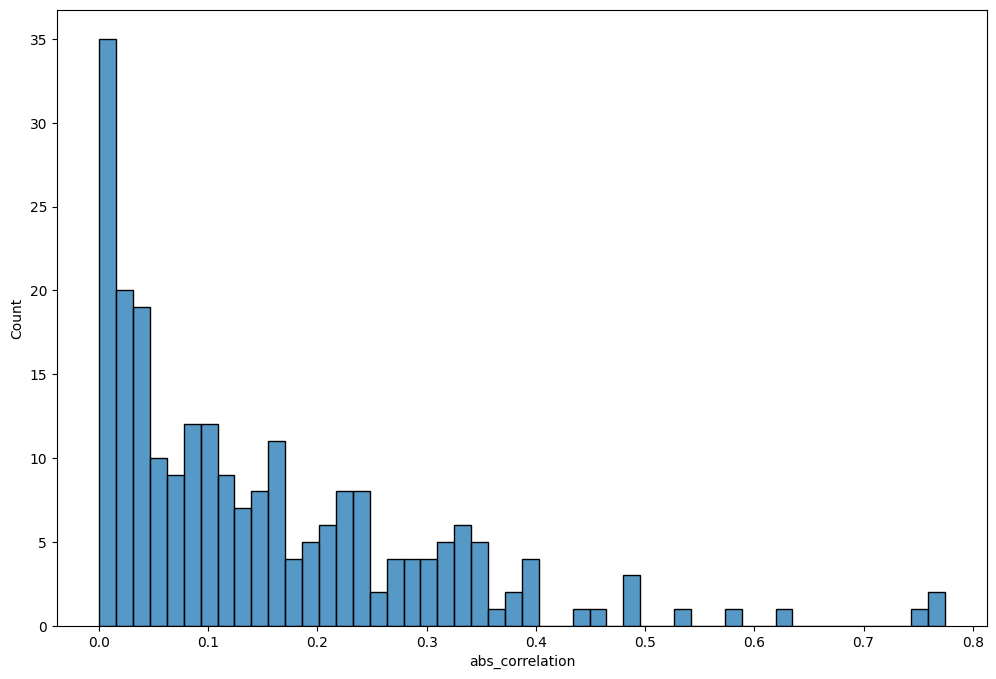

In [0]:
plt.figure(figsize=(12, 8))
sns.histplot(tidy["abs_correlation"], bins = 50)

# correlation histogram for frequency looks like there are a couple above 0.5

In [0]:
tidy[tidy['abs_correlation'] > 0.5].sort_values('abs_correlation', ascending=False)

# identify highly correlated features (|r| > 0.5) to monitor multicollinearity risk

,feature1,feature2,correlation,abs_correlation
115,internet_type_Fiber Optic,monthly,0.774253,0.774253
130,internet_type_None,monthly,-0.763557,0.763557
127,internet_type_None,unlimited,-0.755734,0.755734
28,contract,months,0.629463,0.629463
52,monthly,unlimited,0.582484,0.582484
122,internet_type_None,gb_mon,-0.528450,0.528450


In [0]:
# moving on to train test split

In [0]:
# install sci-kit learn for azure ML
import sys

!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [0]:
from sklearn.model_selection import train_test_split

In [0]:
# use 80/20 split to maximize training data while preserving evaluation integrity

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 123)

In [0]:
# check if done properly

print(x_train.shape)
print(y_train.shape)

(5634, 22)
(5634,)


In [0]:
# check if done properly

print(x_test.shape)
print(y_test.shape)

(1409, 22)
(1409,)


In [0]:
from sklearn.linear_model import LogisticRegression

In [0]:
# lets make our LogisticRegression model

lr_l2 = LogisticRegression(
    random_state = 123,
    penalty = 'l2',
    solver = 'lbfgs',
    max_iter = 2000,
    class_weight = 'balanced'
)

In [0]:
lr_l2.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=123)

In [0]:
lr_l2_preds = lr_l2.predict(x_test)

In [0]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [0]:
print(accuracy_score(y_test, lr_l2_preds))

# accuracy score

precision_recall_fscore_support(y_test, lr_l2_preds, average = 'binary')

# strong performance across precision/recall/F1 for churn detection

0.9446415897799858


(0.8529411764705882, 0.9508196721311475, 0.8992248062015503, None)

In [0]:
# trying l1 to see if the score is better or worse

lr_l1 = LogisticRegression(
    random_state = 123,
    penalty = 'l1',
    solver = 'liblinear',
    max_iter = 2000,
    class_weight = 'balanced'
)

In [0]:
lr_l1.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, penalty='l1',
                   random_state=123, solver='liblinear')

In [0]:
lr_l1_preds = lr_l1.predict(x_test)

In [0]:
odd_ratios = lr_l1.predict_proba(x_test.iloc[:1,:])
odd_ratios

# predicted class probabilities for a single customer (model confidence)

array([[0.57584648, 0.42415352]])

In [0]:
lr_l1.predict(x_test.iloc[:1,:])

array([0])

In [0]:
print(accuracy_score(y_test, lr_l1_preds))

precision_recall_fscore_support(y_test, lr_l1_preds, average = 'binary')

# it looks like there is a very slight boost to all of these metrics (~0.2%) for l1

0.9467707594038325


(0.8574938574938575, 0.953551912568306, 0.9029754204398448, None)

In [0]:
from sklearn.metrics import confusion_matrix

In [0]:
# lets see a visual aid confusion matrix for l1 predictions
cf = confusion_matrix(y_test, lr_l1_preds, normalize= 'true')

cf


array([[0.94439118, 0.05560882],
       [0.04644809, 0.95355191]])

In [0]:
from sklearn.metrics import ConfusionMatrixDisplay

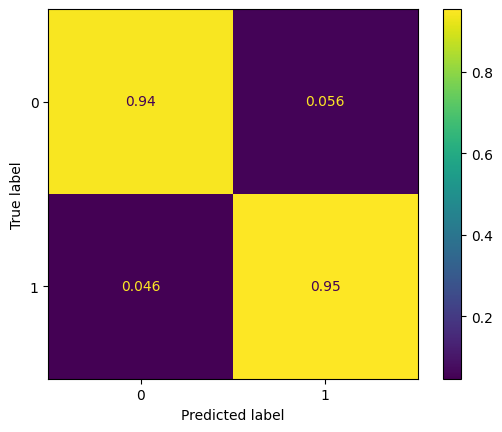

In [0]:
disp = ConfusionMatrixDisplay(confusion_matrix = cf)
disp.plot()
plt.show()

# normalize confusion matrix to interpret class wise prediction rates

In [0]:
lr_l1.coef_

array([[-6.01073118e-01,  1.57584317e-01, -7.86169712e-01,
        -3.37107845e+00, -2.75540515e-01,  5.30148246e-02,
        -6.76454968e-01, -1.75017418e-01, -1.64660931e+00,
         5.12605132e-01,  1.40621056e+00, -2.54634932e+01,
        -4.66450454e-01, -4.24707276e-02, -2.04375434e-01,
         3.69619163e-03, -9.08609641e-01,  8.13575673e-01,
        -3.49511595e-01, -1.86649080e-01, -4.67247707e-01,
         6.69884586e-01]])

In [0]:
import numpy as np

In [0]:
# lets graph the coefficients. this isnt as accurate as linear regression but it still gives a sense of the impact of each feature

def plot_logreg_coefs(model, columns):
    coefs = -model.coef_[0]
    # flip sign for interpretability: positive = retention, negative = churn risk
    features = np.asarray(columns)


    
    # sort
    order = np.argsort(coefs)
    coefs = coefs[order]
    features = features[order]


    
    colors = np.where(coefs < 0, "r", "g")


    plt.barh(features, coefs, color=colors)
    plt.xlabel("Coefficient")
    plt.title("LogReg Coefs (class 0)")
    plt.show()

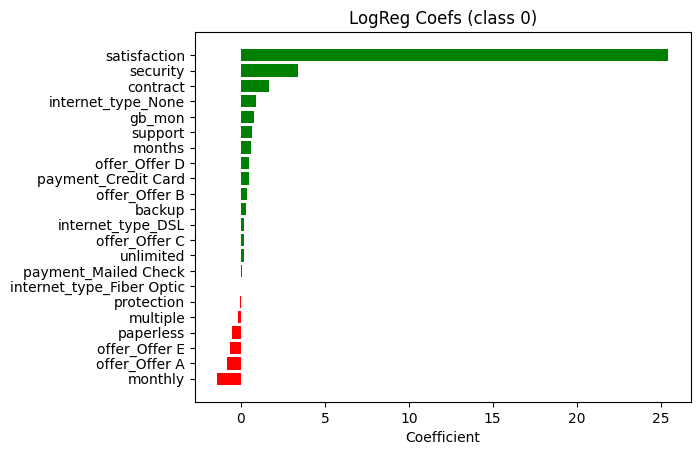

In [0]:
plot_logreg_coefs(lr_l1, x.columns)

In [0]:
# we can see that higher satisfaction has a massive impact in higher not churn (keeping customers)
# we can see that higher monthly (monthly bill amount) has the biggest impact in lower not churn (losing customers)

In [0]:
# now lets try elastic net

lr_elastic_net = LogisticRegression(
    random_state = 123,
    penalty = 'elasticnet',
    solver = 'saga',
    max_iter = 2000,
    class_weight = 'balanced',
    l1_ratio = 0.1
)

In [0]:
lr_elastic_net.fit(x_train, y_train)
lr_elastic_net_preds = lr_elastic_net.predict(x_test)

In [0]:
print(accuracy_score(y_test, lr_elastic_net_preds))

precision_recall_fscore_support(y_test, lr_elastic_net_preds, average = 'binary')

# very similar to L2 (ridge)

0.9446415897799858


(0.8529411764705882, 0.9508196721311475, 0.8992248062015503, None)

In [0]:
cf = confusion_matrix(y_test, lr_elastic_net_preds, normalize= 'true')

cf

array([[0.94247363, 0.05752637],
       [0.04918033, 0.95081967]])

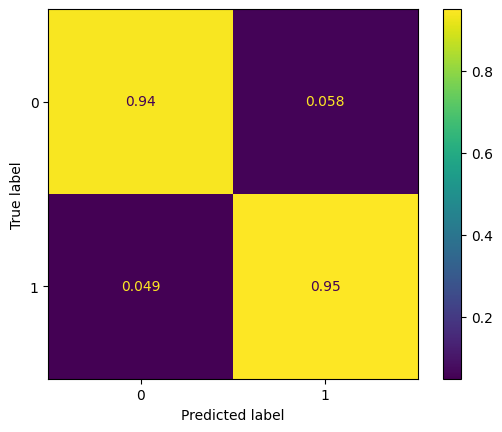

In [0]:
disp = ConfusionMatrixDisplay(confusion_matrix = cf)
disp.plot()
plt.show()

# very similar confusion matrix (all good)

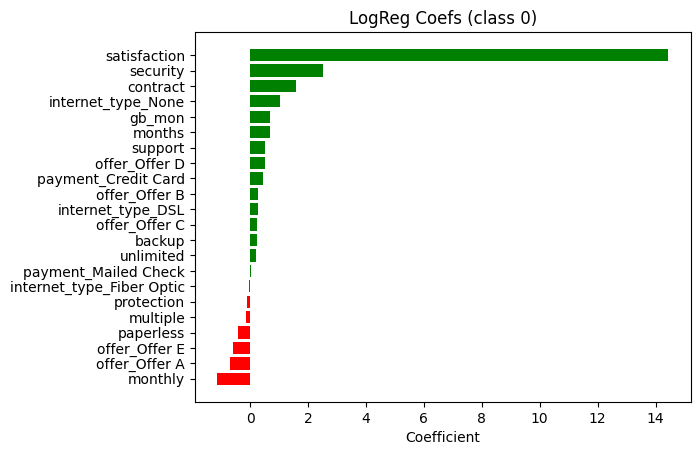

In [0]:
plot_logreg_coefs(lr_elastic_net, x.columns)

In [0]:
# here we can see a significant difference in the coefficient for satisfaction.
# for L1 the satisfaction coefficient was ~25 
# for elastic net the satisfaction coefficient is ~14
# this makes sense because there is a much higher mix of L2 in our parameter and L2 penalizes large coefficients heavily

In [0]:
models = {
    "L2": lr_l2_preds,
    "L1": lr_l1_preds,
    "ElasticNet": lr_elastic_net_preds
}

rows = []

for name, preds in models.items():
    acc = accuracy_score(y_test, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, preds, average='binary'
    )

    
    rows.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(rows)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,L2,0.944642,0.852941,0.950820,0.899225
1,L1,0.946771,0.857494,0.953552,0.902975
2,ElasticNet,0.944642,0.852941,0.950820,0.899225


In [0]:
# all models are very similar with great scores with L1 barely coming out on top by ~+0.2% across all scores

In [0]:
# now lets try the KNN (K Nearest Neighbors) Model

In [0]:
# we have our data already loaded

In [0]:
from IPython.display import display

In [0]:
with pd.option_context('display.max_columns', None):
    display(data.describe())

# lets see every column to see if theyre linear. also to see if theyre scaled or not.
# looks like theyre all linear and theyre all scaled from 0 to 1 (min max scaling)

,months,multiple,gb_mon,security,backup,protection,support,unlimited,contract,paperless,monthly,satisfaction,churn_value,payment_Credit Card,payment_Mailed Check,internet_type_DSL,internet_type_Fiber Optic,internet_type_None,offer_Offer A,offer_Offer B,offer_Offer C,offer_Offer D,offer_Offer E
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.433551,0.421837,0.241358,0.286668,0.344881,0.343888,0.290217,0.673719,0.377396,0.592219,0.462803,0.561231,0.265370,0.390317,0.054664,0.234559,0.430924,0.216669,0.073832,0.116996,0.058924,0.085475,0.114298
std,0.398231,0.493888,0.240223,0.452237,0.475363,0.475038,0.453895,0.468885,0.424234,0.491457,0.299403,0.300414,0.441561,0.487856,0.227340,0.423753,0.495241,0.412004,0.261516,0.321438,0.235499,0.279607,0.318195
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.035294,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.171642,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.250000,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.518408,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.750000,1.000000,0.317647,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.712438,0.750000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [0]:
x = data.drop("churn_value", axis = 1)
y = data["churn_value"]


In [0]:
y.value_counts(normalize = True)

# looks like 73.5% has not churned and 26.5% has churned

0    0.73463
1    0.26537
Name: churn_value, dtype: float64

<Axes: >

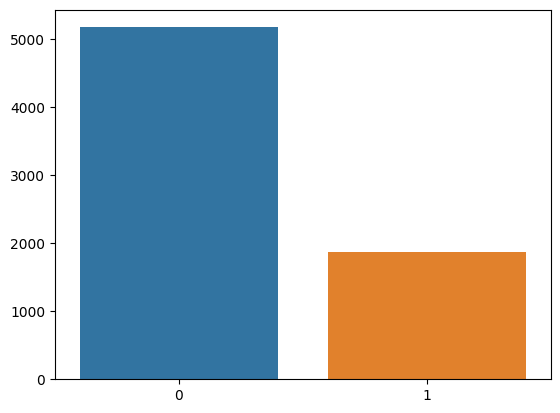

In [0]:
sns.barplot(x = y.value_counts().index, y = y.value_counts().values)

# this is a moderate imbalance ~(75/25)

In [0]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, stratify = y, random_state = 123)

# we have ~7000 samples so 80/20 is the best we can get away with

In [0]:
from sklearn.neighbors import KNeighborsClassifier

In [0]:
knn = KNeighborsClassifier(n_neighbors=2)

In [0]:
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [0]:
knn_preds = knn.predict(x_test)

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fc68878a680>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
/databricks/python/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:237: FutureWarning: Unlike other reduction functions (e

In [0]:
knn_accuracy_2 = accuracy_score(y_test, knn_preds)
knn_precision_2, knn_recall_2, knn_fscore_2, _ = precision_recall_fscore_support(y_test, knn_preds, average = 'binary')

print(accuracy_score(y_test, knn_preds))
print(precision_recall_fscore_support(y_test, knn_preds, average = 'binary'))

# 0.86 accuracy great
# 0.83 precision great
# 0.59 recall not great
# 0.69 f score okay

0.8601845280340668
(0.8314606741573034, 0.5935828877005348, 0.6926677067082684, None)


In [0]:
# we will find the best k value by comparing f-score
# f-score because:
# 1. class imbalance (way more 0's than 1's here)
# 2. care about both (not churn is also important)

In [0]:
max_k = 50
f1_scores = []

In [0]:
from sklearn.metrics import f1_score

In [0]:
for k in range(1, max_k +1): 
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(x_train, y_train)
    knn_preds = knn.predict(x_test)
    f1 = f1_score(y_test, knn_preds)
    f1_scores.append((k, round(f1, 4)))

f1_results = pd.DataFrame(f1_scores, columns = ["k", "f1 score"])
f1_results.set_index('k')



Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fc6886b48b0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
/databricks/python/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:237: FutureWarning: Unlike other reduction functions (e

,f1 score
k,
1,0.7246
2,0.6927
3,0.7357
4,0.7166
5,0.7312
6,0.7361
7,0.7541
8,0.7504
9,0.7552


<Axes: xlabel='k', ylabel='f1 score'>

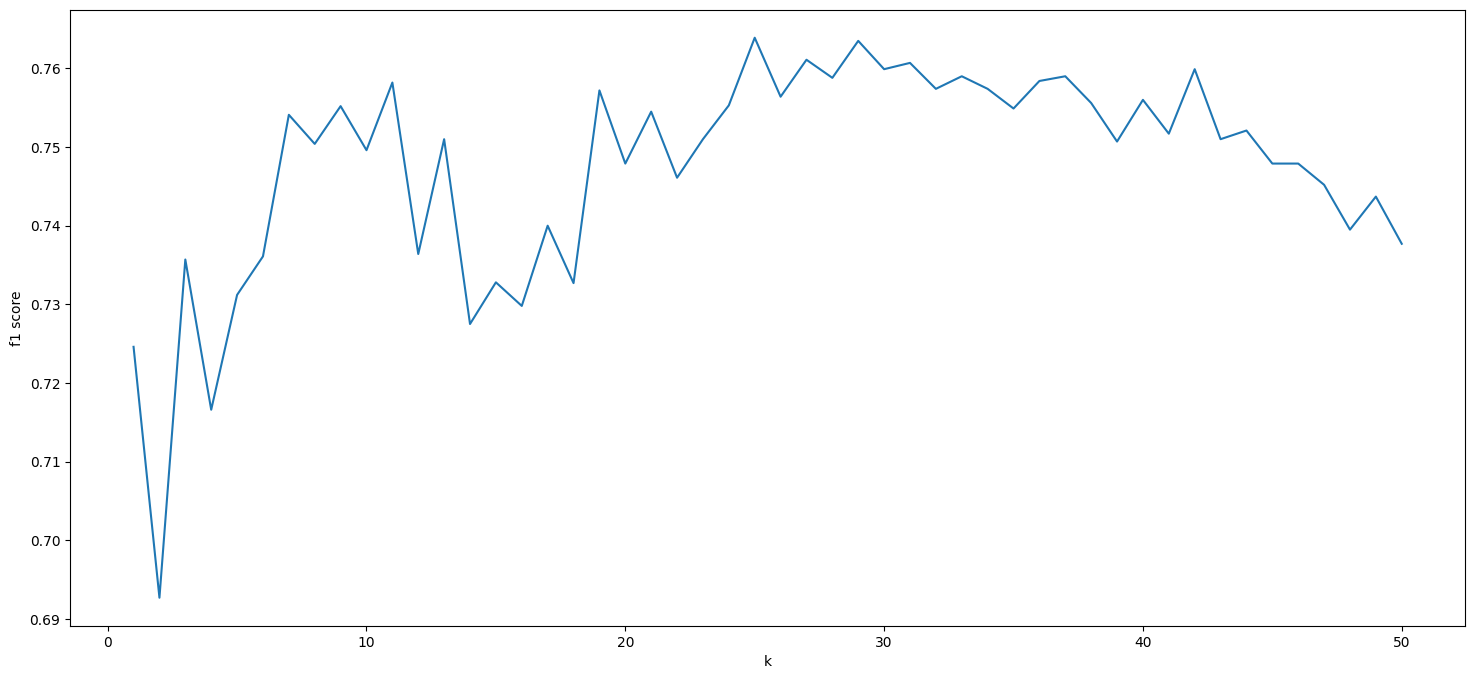

In [0]:
# much easier to see in a line graph
plt.figure(figsize = (18, 8))
sns.lineplot(x = 'k', y = 'f1 score', data = f1_results)


In [0]:
# optimal k selected based on F1 (balances precision and recall under class imbalance)

In [0]:
knn = KNeighborsClassifier(n_neighbors=25)
knn.fit(x_train, y_train)
knn_preds = knn.predict(x_test)

knn_accuracy_25 = accuracy_score(y_test, knn_preds)
knn_precision_25, knn_recall_25, knn_fscore_25, _ = precision_recall_fscore_support(y_test, knn_preds, average = 'binary')


print(accuracy_score(y_test, knn_preds))
print(precision_recall_fscore_support(y_test, knn_preds, average = 'binary'))

# here are the official accuracy, precision, recall, and fscore


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fc6886fe3b0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


0.879347054648687
(0.7947976878612717, 0.7352941176470589, 0.7638888888888888, None)


/databricks/python/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:237: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [0]:
from IPython.display import display, Markdown

In [0]:
knn_table = pd.DataFrame(
    [
        ["k = 2", knn_accuracy_2, knn_precision_2, knn_recall_2, knn_fscore_2],
        ["k = 25", knn_accuracy_25, knn_precision_25, knn_recall_25, knn_fscore_25]
    ],
    columns = ["K value", "Accuracy", "Precision", "Recall", "Fscore"]
)


display(Markdown("##### KNN Performance Comparison"))
display(knn_table.style.hide(axis="index"))

##### KNN Performance Comparison

K value,Accuracy,Precision,Recall,Fscore
k = 2,0.860185,0.831461,0.593583,0.692668
k = 25,0.879347,0.794798,0.735294,0.763889


In [0]:
# here we can see we gained on all except precision with k = 25. we see significant gains on recall

In [0]:
# now lets look at SVM (support vector machines) and kernels

In [0]:
data = spark.table(
    "churn_project_databricks.default.churndata_processed"
).toPandas()

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   months                     7043 non-null   float64
 1   multiple                   7043 non-null   int64  
 2   gb_mon                     7043 non-null   float64
 3   security                   7043 non-null   int64  
 4   backup                     7043 non-null   int64  
 5   protection                 7043 non-null   int64  
 6   support                    7043 non-null   int64  
 7   unlimited                  7043 non-null   int64  
 8   contract                   7043 non-null   float64
 9   paperless                  7043 non-null   int64  
 10  monthly                    7043 non-null   float64
 11  satisfaction               7043 non-null   float64
 12  churn_value                7043 non-null   int64  
 13  payment_Credit Card        7043 non-null   int64

In [0]:
x_v2 = data.drop("churn_value", axis = 1)
y_v2 = data["churn_value"]

In [0]:
x_v2train, x_v2test, y_v2train, y_v2test = train_test_split(x_v2, y_v2, test_size = 0.2, stratify = y_v2, random_state = 123)

In [0]:
from sklearn.svm import SVC

# import the SVC (support vector classifier)
# this is SVM for classification

In [0]:
svc = SVC()

In [0]:
%%timeit
svc.fit(x_v2train, y_v2train)

288 ms ± 41.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [0]:
svc_preds = svc.predict(x_v2test)

In [0]:
svc_accuracy = accuracy_score(y_v2test, svc_preds)
svc_precision, svc_recall, svc_fscore, _ = precision_recall_fscore_support(y_v2test, svc_preds, average = 'binary')

print(accuracy_score(y_v2test, svc_preds))
print(precision_recall_fscore_support(y_v2test, svc_preds, average = 'binary'))

# accuracy = 0.95 great
# precision = 0.92 great
# recall = 0.88 great
# f score = 0.90 great

0.9474804826117814
(0.9166666666666666, 0.8823529411764706, 0.8991825613079019, None)


In [0]:
# now lets change the hyperparameters for SVC(), specifically the C value and the kernel

svc_rbf = SVC(C = 10, kernel = 'rbf')

In [0]:
%%timeit
svc_rbf.fit(x_v2train, y_v2train)

268 ms ± 24.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [0]:
svc_rbf_preds = svc_rbf.predict(x_v2test)

svc_rbf_accuracy = accuracy_score(y_v2test, svc_preds)
svc_rbf_precision, svc_rbf_recall, svc_rbf_fscore, _ = precision_recall_fscore_support(y_v2test, svc_rbf_preds, average = 'binary')

print(accuracy_score(y_v2test, svc_preds))
print(precision_recall_fscore_support(y_v2test, svc_rbf_preds, average = 'binary'))

# accuracy = 0.95 great
# precision = 0.88 great
# recall = 0.90 great
# f score = 0.89 great

0.9474804826117814
(0.881578947368421, 0.8957219251336899, 0.8885941644562334, None)


In [0]:
params_grid = {
    "C" : [1, 10, 100],
    "kernel" : ["poly", "rbf", "sigmoid"]
}

In [0]:
svc_gridsearch = SVC()

In [0]:
from sklearn.model_selection import GridSearchCV

In [0]:
grid_search = GridSearchCV(estimator = svc_gridsearch,
                           param_grid = params_grid,
                           scoring = 'f1',
                           cv = 5, verbose = 1)


In [0]:
%%timeit
grid_search.fit(x_v2train, y_v2train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Fitting 5 folds for each of 9 candidates, totalling 45 fits
12.2 s ± 398 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [0]:
best_params = grid_search.best_params_

In [0]:
best_params

# we can see the best params are C = 1, kernel = poly

{'C': 1, 'kernel': 'poly'}

In [0]:
# lets see the scores for this model 

svc_best = SVC(C = 1, kernel = "poly")

In [0]:
%%timeit
svc_best.fit(x_v2train, y_v2train)

196 ms ± 23 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [0]:
svc_best_preds = svc_best.predict(x_v2test)

svc_best_accuracy = accuracy_score(y_v2test, svc_best_preds)
svc_best_precision, svc_best_recall, svc_best_fscore, _ = precision_recall_fscore_support(y_v2test, svc_best_preds, average = 'binary')

print(accuracy_score(y_v2test, svc_best_preds))
print(precision_recall_fscore_support(y_v2test, svc_best_preds, average = 'binary'))

# accuracy = 0.95 great
# precision = 0.90 great
# recall = 0.89 great
# f score = 0.90 great

0.9453513129879347
(0.9002695417789758, 0.893048128342246, 0.8966442953020135, None)


In [0]:
SVC_table = pd.DataFrame(
    [
        [svc_accuracy, svc_precision, svc_recall, svc_fscore],
        [svc_rbf_accuracy, svc_rbf_precision, svc_rbf_recall, svc_rbf_fscore],
        [svc_best_accuracy, svc_best_precision, svc_best_recall, svc_best_fscore]
    ],
    columns = ["Accuracy", "Precision", "Recall", "Fscore"],
    index = ["Default parameters - (C = 1, kernel = poly)", 
             "Trial - (C = 10, kernel = rbf)",
             "GridSearchCV Best - (C = 1, kernel = poly)"]
)

display(Markdown("##### SVC Performance Comparison"))
SVC_table

# it looks like the default parameters (C = 1, kernel = poly) 
# is the most balanced performer as it is 
# tied highest for accuracy with trial,
# has much higher precision than trial, 
# has slighty lower recall than trial, and 
# higher Fscore than trial.

##### SVC Performance Comparison

,Accuracy,Precision,Recall,Fscore
"Default parameters - (C = 1, kernel = poly)",0.947480,0.916667,0.882353,0.899183
"Trial - (C = 10, kernel = rbf)",0.947480,0.881579,0.895722,0.888594
"GridSearchCV Best - (C = 1, kernel = poly)",0.945351,0.900270,0.893048,0.896644


In [0]:
# lets try decision trees now

In [0]:
data = spark.table(
    "churn_project_databricks.default.churndata_processed"
).toPandas()

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   months                     7043 non-null   float64
 1   multiple                   7043 non-null   int64  
 2   gb_mon                     7043 non-null   float64
 3   security                   7043 non-null   int64  
 4   backup                     7043 non-null   int64  
 5   protection                 7043 non-null   int64  
 6   support                    7043 non-null   int64  
 7   unlimited                  7043 non-null   int64  
 8   contract                   7043 non-null   float64
 9   paperless                  7043 non-null   int64  
 10  monthly                    7043 non-null   float64
 11  satisfaction               7043 non-null   float64
 12  churn_value                7043 non-null   int64  
 13  payment_Credit Card        7043 non-null   int64

In [0]:
x_v3 = data.drop("churn_value", axis = 1)
y_v3 = data["churn_value"]

In [0]:
x_v3train, x_v3test, y_v3train, y_v3test = train_test_split(x_v3, y_v3, test_size = 0.2, stratify = y_v3, random_state = 123)

In [0]:
from sklearn.tree import DecisionTreeClassifier

In [0]:
DTC = DecisionTreeClassifier(random_state = 123)

In [0]:
DTC.fit(x_v3train, y_v3train)

DecisionTreeClassifier(random_state=123)

In [0]:
DTC_preds = DTC.predict(x_v3test)

In [0]:
DTC_accuracy = accuracy_score(y_v3test, DTC_preds)
DTC_precision, DTC_recall, DTC_fscore, _ = precision_recall_fscore_support(y_v3test, DTC_preds, average = 'binary')

print(accuracy_score(y_v3test, DTC_preds))
print(precision_recall_fscore_support(y_v3test, DTC_preds, average = 'binary'))

# 0.93 accuracy score great
# 0.86 precision great
# 0.89 recall great
# 0.87 fscore great

0.9318665720369056
(0.8564102564102564, 0.893048128342246, 0.8743455497382198, None)


In [0]:
from sklearn import tree

In [0]:
# lets try and plot the tree out to get a visual aid of whats going on

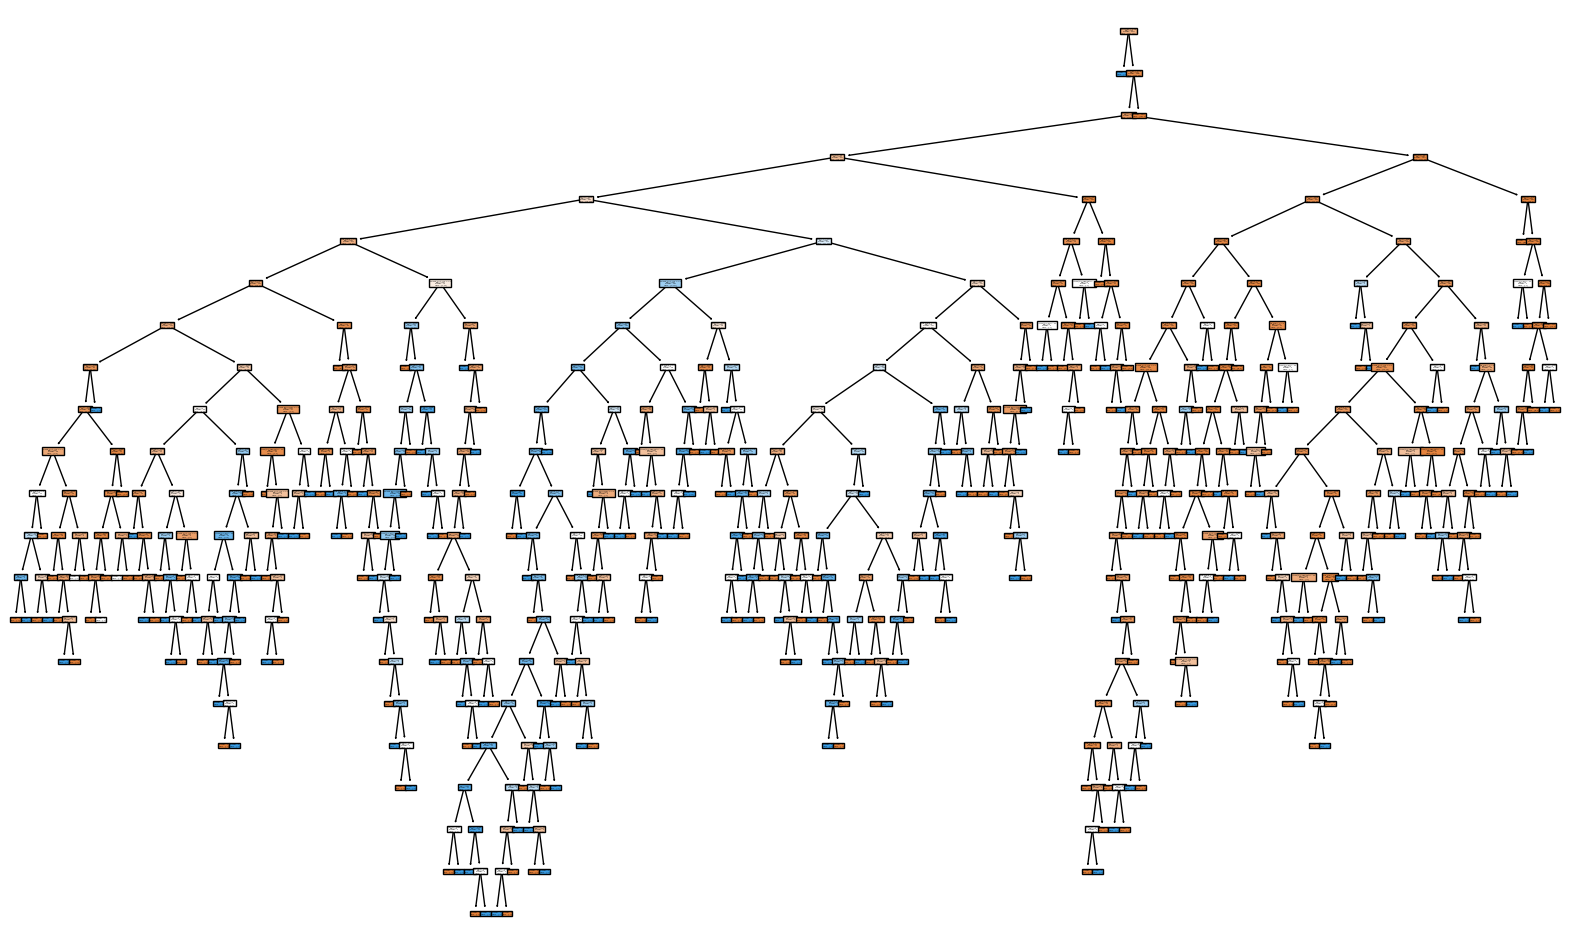

In [0]:
plt.figure(figsize = (20,12))
tree.plot_tree(DTC,
               feature_names = x_v3.columns.values,
               filled=True)
plt.show()

In [0]:
DTC.tree_.node_count, DTC.tree_.max_depth

# here we can see we have 625! nodes and 21 levels deep

(625, 21)

In [0]:
# the text is pretty much unreadable but we can get a general idea of whats going on
# the tree is too big (maybe overfit)

In [0]:
DTC_train_score = DTC.score(x_v3train, y_v3train)
DTC_test_score = DTC.score(x_v3test, y_v3test)

print(DTC_train_score)
print(DTC_test_score)

# this is proof of overfitting as we have a high training score and a high test score (that is lower than the training score)

0.9992900248491303
0.9318665720369056


In [0]:
# lets try criterion = 'entropy', max_depth = 10, min_samples_leaf = 3

DTC_custom = DecisionTreeClassifier(criterion = 'entropy', max_depth = 10, min_samples_leaf = 3)

In [0]:
DTC_custom.fit(x_v3train, y_v3train)
DTC_custom_preds = DTC_custom.predict(x_v3test)

In [0]:
DTC_custom_accuracy = accuracy_score(y_v3test, DTC_custom_preds)
DTC_custom_precision, DTC_custom_recall, DTC_custom_fscore, _ = precision_recall_fscore_support(y_v3test, DTC_custom_preds, average = 'binary')

print(accuracy_score(y_v3test, DTC_custom_preds))
print(precision_recall_fscore_support(y_v3test, DTC_custom_preds, average = 'binary'))

# 0.93 accuracy score great
# 0.86 precision score great
# 0.90 recall score great
# 0.88 fscore great

0.9347054648687012
(0.8634020618556701, 0.8957219251336899, 0.8792650918635171, None)


In [0]:
DTC_custom_train_score = DTC_custom.score(x_v3train, y_v3train)
DTC_custom_test_score = DTC_custom.score(x_v3test, y_v3test)

print(DTC_custom_train_score)
print(DTC_custom_test_score)
# less overfit! but still slightly overfit

0.9660986865459709
0.9347054648687012


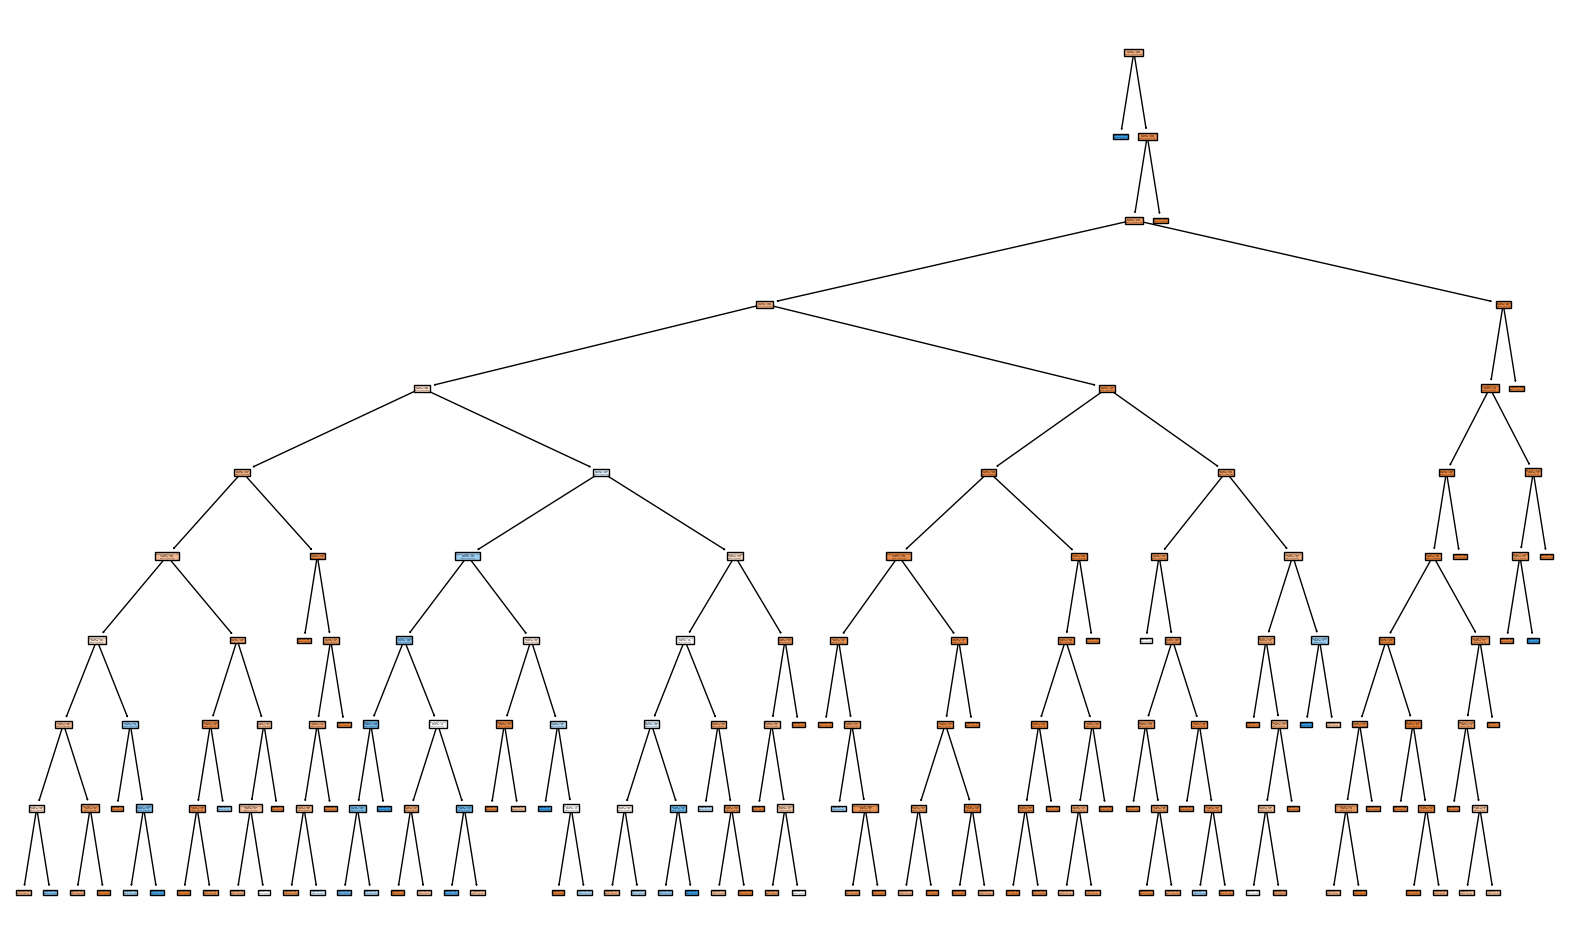

In [0]:
plt.figure(figsize = (20,12))
tree.plot_tree(DTC_custom,
               feature_names = x_v3.columns.values,
               filled=True)
plt.show()

# much smaller tree so its a less complex model. still cant see labels though

In [0]:
DTC_custom2 = DecisionTreeClassifier(criterion = 'gini', max_depth = 15, min_samples_leaf = 5)

# lets try gini, max depth 15, and min samples leaf 5

In [0]:
DTC_custom2.fit(x_v3train, y_v3train)
DTC_custom2_preds = DTC_custom2.predict(x_v3test)

In [0]:
DTC_custom2_accuracy = accuracy_score(y_v3test, DTC_custom2_preds)
DTC_custom2_precision, DTC_custom2_recall, DTC_custom2_fscore, _ = precision_recall_fscore_support(y_v3test, DTC_custom2_preds, average = 'binary')

print(accuracy_score(y_v3test, DTC_custom2_preds))
print(precision_recall_fscore_support(y_v3test, DTC_custom2_preds, average = 'binary'))

# 0.935 accuracy score the same as the first custom model
# 0.877 precision score slightly better than the first custom model
# 0.88 recall score slightly worse than the first custom model
# 0.879 support slightly worse than the first custom model

0.9354151880766501
(0.8753315649867374, 0.8823529411764706, 0.8788282290279626, None)


In [0]:
DTC_custom2_train_score = DTC_custom2.score(x_v3train, y_v3train)
DTC_custom2_test_score = DTC_custom2.score(x_v3test, y_v3test)

print(DTC_custom2.score(x_v3train, y_v3train))
print(DTC_custom2.score(x_v3test, y_v3test))

# slightly overfit like the first custom model

0.9703585374511892
0.9354151880766501


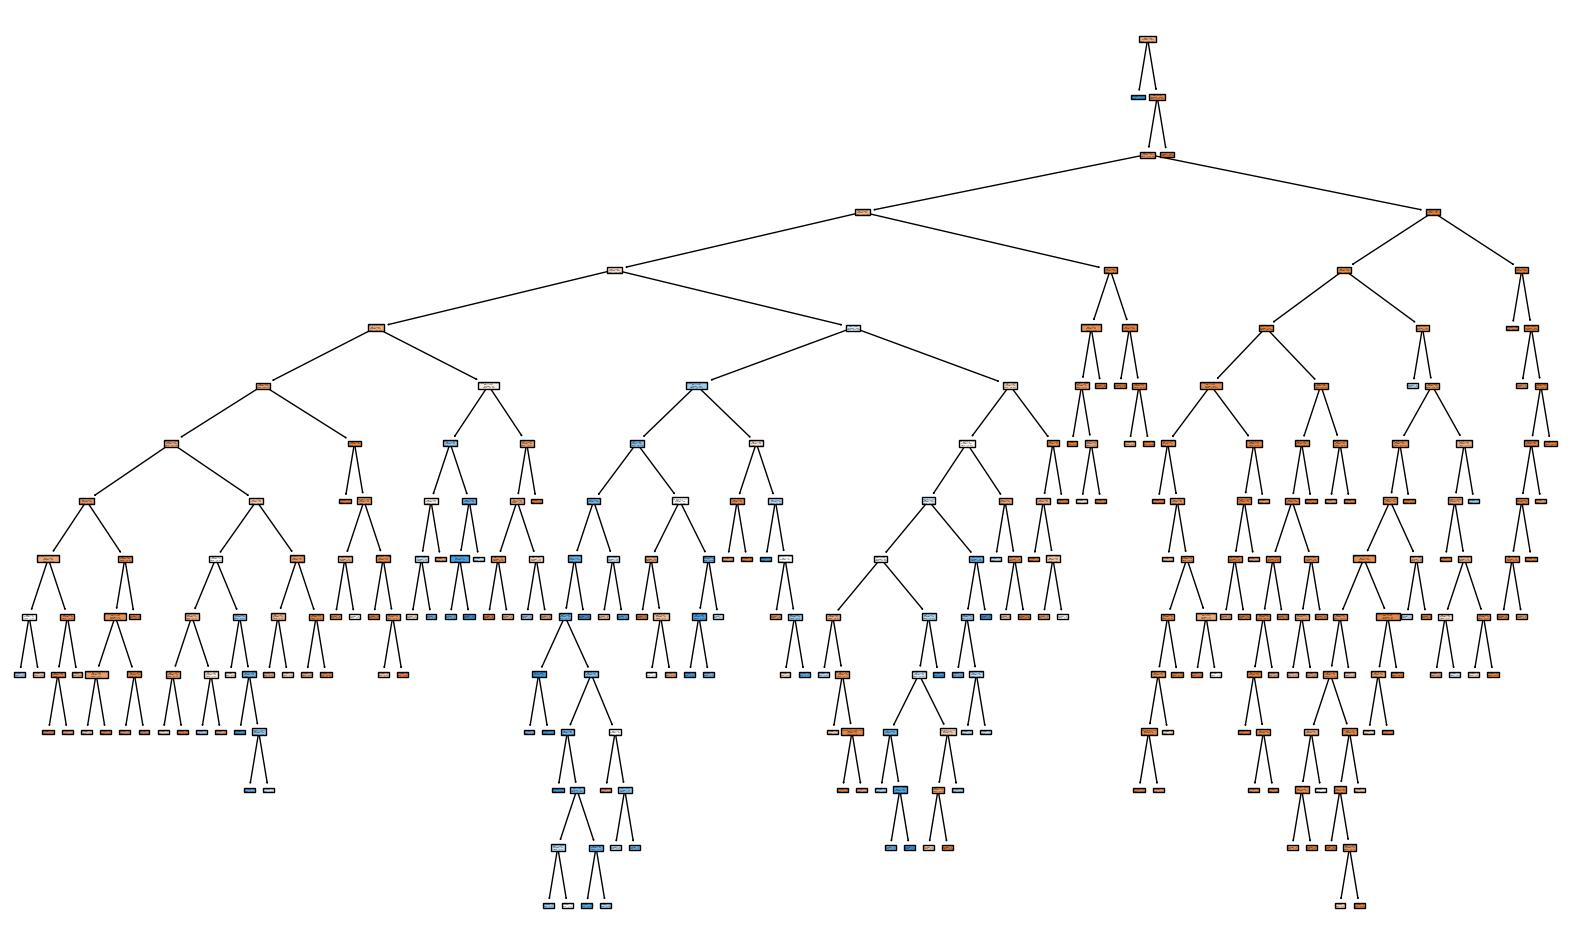

In [0]:
plt.figure(figsize = (20,12))
tree.plot_tree(DTC_custom2,
               feature_names = x_v3.columns.values,
               filled=True)
plt.show()

# this look similarly complex as the first custom model

In [0]:
params_grid = {
    'criterion': ["entropy", "gini"],
    "max_depth": [5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 5]
}

In [0]:
DTC_gridsearch = DecisionTreeClassifier(random_state = 123)

In [0]:
DTC_grid_search = GridSearchCV(estimator = DTC_gridsearch,
                               param_grid = params_grid,
                               scoring = 'f1',
                               cv = 5, verbose = 1)
DTC_grid_search.fit(x_v3train, y_v3train)
best_params = DTC_grid_search.best_params_

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [0]:
best_params

{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5}

In [0]:
DTC_best = DecisionTreeClassifier(criterion = 'entropy', max_depth = 10, min_samples_leaf = 5)
DTC_best.fit(x_v3train, y_v3train)
DTC_best_preds = DTC_best.predict(x_v3test)

In [0]:
DTC_best_accuracy = accuracy_score(y_v3test, DTC_best_preds)
DTC_best_precision, DTC_best_recall, DTC_best_fscore, _ = precision_recall_fscore_support(y_v3test, DTC_best_preds, average = 'binary')

print(accuracy_score(y_v3test, DTC_best_preds))
print(precision_recall_fscore_support(y_v3test, DTC_best_preds, average = 'binary'))

# 0.93 accuracy score great
# 0.858 precision score great
# 0.90 recall score great
# 0.879 support great

0.9347054648687012
(0.8615384615384616, 0.8983957219251337, 0.8795811518324609, None)


In [0]:
DTC_best_train_score = DTC_best.score(x_v3train, y_v3train)
DTC_best_test_score = DTC_best.score(x_v3test, y_v3test)

print(DTC_best.score(x_v3train, y_v3train))
print(DTC_best.score(x_v3test, y_v3test))

# slightly overfit

0.9653887113951012
0.9347054648687012


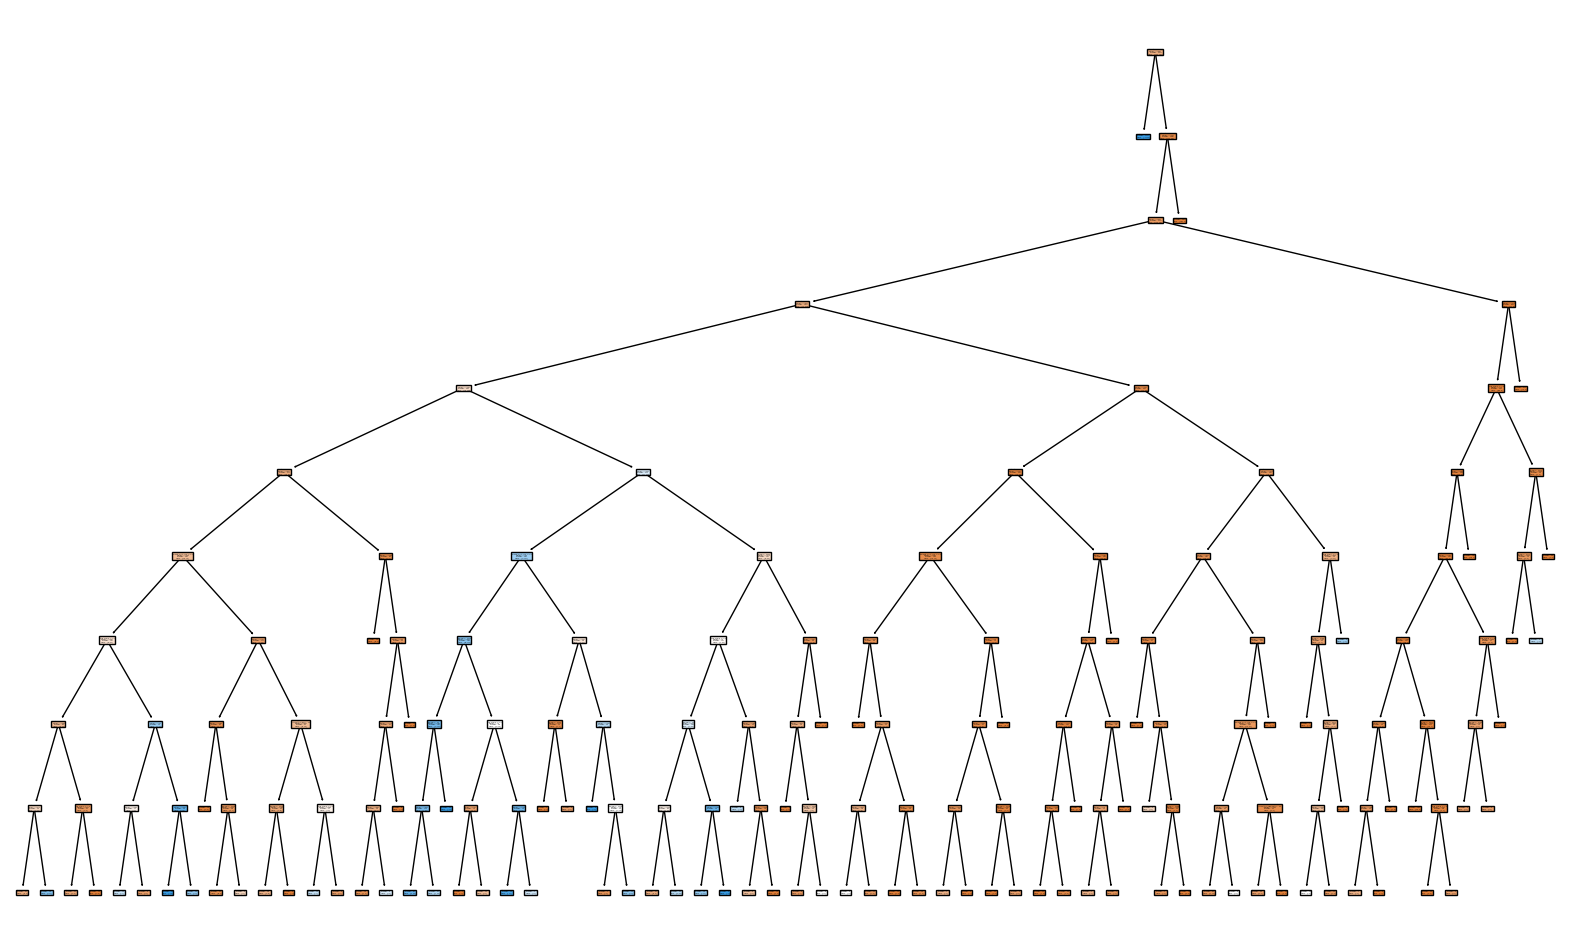

In [0]:
plt.figure(figsize = (20,12))
tree.plot_tree(DTC_best,
               feature_names = x_v3.columns.values,
               filled=True)
plt.show()


In [0]:
DTC_grid_search.best_estimator_.tree_.node_count, DTC_grid_search.best_estimator_.tree_.max_depth

# the best parameters had 179 nodes and 10 levels deep

(179, 10)

In [0]:
DTC_table = pd.DataFrame(
    [
        [DTC_accuracy, DTC_precision, DTC_recall, DTC_fscore, DTC_train_score, DTC_test_score],
        [DTC_custom_accuracy, DTC_custom_precision, DTC_custom_recall, DTC_custom_fscore, DTC_custom_train_score, DTC_custom_test_score],
        [DTC_custom2_accuracy, DTC_custom2_precision, DTC_custom2_recall, DTC_custom2_fscore, DTC_custom2_train_score, DTC_custom2_test_score],
        [DTC_best_accuracy, DTC_best_precision, DTC_best_recall, DTC_best_fscore, DTC_best_train_score, DTC_best_test_score]
    ],
    columns = ["Accuracy", "Precision", "Recall", "Fscore", "Train score", "Test score"],
    index = ["Default parameters - (criterion = 'gini', max_depth = None, min_samples_leaf = 1)", 
             "Custom 1 - (criterion = 'entropy', max_depth = 10, min_samples_leaf = 3)",
             "Custom 2 - (criterion = 'gini', max_depth = 15, min_samples_leaf = 5)",
             "GridSearchCV Best - (criterion = 'entropy', max_depth = 10, min_samples_leaf = 5)"]
)

display(Markdown("##### DTC Performance Comparison"))
DTC_table

##### DTC Performance Comparison

,Accuracy,Precision,Recall,Fscore,Train score,Test score
"Default parameters - (criterion = 'gini', max_depth = None, min_samples_leaf = 1)",0.931867,0.856410,0.893048,0.874346,0.999290,0.931867
"Custom 1 - (criterion = 'entropy', max_depth = 10, min_samples_leaf = 3)",0.934705,0.863402,0.895722,0.879265,0.966099,0.934705
"Custom 2 - (criterion = 'gini', max_depth = 15, min_samples_leaf = 5)",0.935415,0.875332,0.882353,0.878828,0.970359,0.935415
"GridSearchCV Best - (criterion = 'entropy', max_depth = 10, min_samples_leaf = 5)",0.934705,0.861538,0.898396,0.879581,0.965389,0.934705


In [0]:
# Default parameters is eliminated because its way too overfit indicated by the train score being way higher than the test score
# Custom 1 and Custom 2 are good for accuracy and precision
# GridSearchCV Best is good for recall

# we can choose which we want based on what is important to us

In [0]:
# Now lets try bagging (bootstrap aggregation)

In [0]:
data = spark.table(
    "churn_project_databricks.default.churndata_processed"
).toPandas()

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   months                     7043 non-null   float64
 1   multiple                   7043 non-null   int64  
 2   gb_mon                     7043 non-null   float64
 3   security                   7043 non-null   int64  
 4   backup                     7043 non-null   int64  
 5   protection                 7043 non-null   int64  
 6   support                    7043 non-null   int64  
 7   unlimited                  7043 non-null   int64  
 8   contract                   7043 non-null   float64
 9   paperless                  7043 non-null   int64  
 10  monthly                    7043 non-null   float64
 11  satisfaction               7043 non-null   float64
 12  churn_value                7043 non-null   int64  
 13  payment_Credit Card        7043 non-null   int64

In [0]:
x_v4 = data.drop("churn_value", axis = 1)
y_v4 = data["churn_value"]

In [0]:
x_v4train, x_v4test, y_v4train, y_v4test = train_test_split(x_v4, y_v4, test_size = 0.2, random_state = 123)

In [0]:
# as we know, decision trees are prone to overfitting

In [0]:
DTC_bad = DecisionTreeClassifier(
    max_depth = None,
    min_samples_split = 2,
    min_samples_leaf = 1, 
    max_features = None,
    random_state = 123)

In [0]:
DTC_bad.fit(x_v4train, y_v4train)

DecisionTreeClassifier(random_state=123)

In [0]:
DTC_bad_preds = DTC_bad.predict(x_v4test)

In [0]:
DTC_bad_train_score = DTC_bad.score(x_v4train, y_v4train)
DTC_bad_test_score = DTC_bad.score(x_v4test, y_v4test)

print(DTC_bad.score(x_v4train, y_v4train))
print(DTC_bad.score(x_v4test, y_v4test))

0.9992900248491303
0.9311568488289567


In [0]:
# this is overfit. lets see how bagging improves this

In [0]:
from sklearn.ensemble import BaggingClassifier

In [0]:
Bag = BaggingClassifier(base_estimator = DTC_bad, n_estimators = 21, random_state = 123, bootstrap = True)

In [0]:
Bag.fit(x_v4train, y_v4train)

BaggingClassifier(base_estimator=DecisionTreeClassifier(random_state=123),
                  n_estimators=21, random_state=123)

In [0]:
Bag.predict(x_v4test)

array([0, 1, 0, ..., 0, 0, 0])

In [0]:
Bag_train_score = Bag.score(x_v4train, y_v4train)
Bag_test_score = Bag.score(x_v4test, y_v4test)

print(Bag.score(x_v4train, y_v4train))
print(Bag.score(x_v4test, y_v4test))

0.9982250621228257
0.9446415897799858


In [0]:
# Bagging has improved the test score from 0.931 -> 0.944 which is a modest improvement. these small percentage improvements are what we can
# realistically see

In [0]:
# install tqdm

import sys

!{sys.executable} -m pip install tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.0 MB/s eta 0:00:00

[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [0]:
from tqdm import tqdm
from sklearn import metrics

In [0]:
# utility function adapted from Joseph Santarcangelo's ML lab materials
# used here to visualize how bagging performance changes as the number of estimators increases

def get_accuracy(X_train, X_test, y_train, y_test, model):
    return  {"test Accuracy":metrics.accuracy_score(y_test, model.predict(X_test)),"train Accuracy": metrics.accuracy_score(y_train, model.predict(X_train))}

In [0]:
# utility function adapted from Joseph Santarcangelo's ML lab materials
# used here to visualize how bagging performance changes as the number of estimators increases
# this locks in max_depth = 10 for the DecisionTreeClassifier and then computes n_estimators from 1 to 70

def get_accuracy_bag(X,y,title,times=20,xlabel='Number Estimators'):


    N_estimators=[n for n in range(1,70)]
    times=20
    train_acc=np.zeros((times,len(N_estimators)))
    test_acc=np.zeros((times,len(N_estimators)))
    
    train_time=np.zeros((times,len(N_estimators)))
    test_time=np.zeros((times,len(N_estimators)))
    for n in tqdm(range(times)):
        X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3)
        for n_estimators in N_estimators:
        
            Bag= BaggingClassifier(estimator=DecisionTreeClassifier(criterion="entropy", max_depth = 10),n_estimators=n_estimators,bootstrap=True,random_state=0)
            Bag.fit(X_train,y_train)
          
            
             
            Accuracy=get_accuracy(X_train, X_test, y_train, y_test,  Bag)
           
            
            
  
            train_acc[n,n_estimators-1]=Accuracy['train Accuracy']
            test_acc[n,n_estimators-1]=Accuracy['test Accuracy']
        
        
        
    fig, ax1 = plt.subplots()

    ax2 = ax1.twinx()
    ax1.plot(train_acc.mean(axis=0))
    ax2.plot(test_acc.mean(axis=0),c='r')
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel('Training accuracy',color='b')
    ax2.set_ylabel('Testing accuracy', color='r')
    plt.title(title)
    plt.show()
    
   

100%|██████████| 20/20 [07:15<00:00, 21.79s/it]


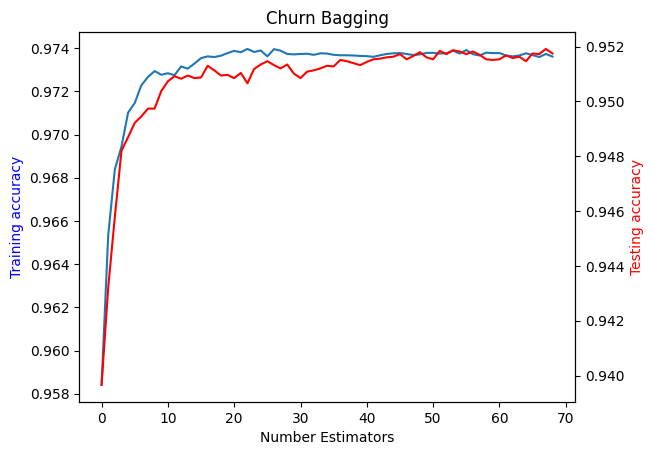

In [0]:
get_accuracy_bag(x_v4, y_v4, "Churn Bagging")

In [0]:
# we can see that test accuracy increases till n_estimators is about ~17 and then peaks at n_estimators ~42 

In [0]:
Bag_table = pd.DataFrame(
    [
        [DTC_bad_train_score, DTC_bad_test_score],
        [Bag_train_score, Bag_test_score]
    ],
    columns = ["Train score", "Test score"],
    index = ["No Bagging - (max_depth = None, min_samples_split = 2, min_samples_leaf = 1, max_features = None)", 
             "Bagging - (n_estimators = 21)"]
)

Bag_table["Overfit gap"] = (
    Bag_table["Train score"] - Bag_table["Test score"]
)

display(Markdown("##### Bagging Performance Comparison"))
Bag_table

##### Bagging Performance Comparison

,Train score,Test score,Overfit gap
"No Bagging - (max_depth = None, min_samples_split = 2, min_samples_leaf = 1, max_features = None)",0.999290,0.931157,0.068133
Bagging - (n_estimators = 21),0.998225,0.944642,0.053583


In [0]:
# decision tree + bagging - moderate increase 
# decision tree + bagging + gridsearchCV - another moderate increase

In [0]:
# now lets try random forest 

In [0]:
# we will be using the bagging parameters and datasets from the bagging section just before this one to improve on the bagging score
# and show how random forest improves overfitting

In [0]:
# function to calculate the average correlation between all the features
# also plots a correlation heatmap


def get_correlation(X_test, y_test,models):
    n_estimators=len(models.estimators_)
    predictions=pd.DataFrame({'estimator '+str(n+1):[] for n in range(n_estimators)})
    for key,model in zip(predictions.keys(),models.estimators_):
        predictions[key]=model.predict(X_test.to_numpy())
    
    corr=predictions.corr()
    print("Average correlation between predictors: ", corr.mean().mean()-1/n_estimators)
    return corr

In [0]:
Bag.estimators_

[DecisionTreeClassifier(random_state=979381764),
 DecisionTreeClassifier(random_state=1540578008),
 DecisionTreeClassifier(random_state=2115349175),
 DecisionTreeClassifier(random_state=745079110),
 DecisionTreeClassifier(random_state=268929039),
 DecisionTreeClassifier(random_state=1421066145),
 DecisionTreeClassifier(random_state=1770928879),
 DecisionTreeClassifier(random_state=1108254685),
 DecisionTreeClassifier(random_state=1151137695),
 DecisionTreeClassifier(random_state=976517999),
 DecisionTreeClassifier(random_state=114881552),
 DecisionTreeClassifier(random_state=21936744),
 DecisionTreeClassifier(random_state=367409930),
 DecisionTreeClassifier(random_state=1379725117),
 DecisionTreeClassifier(random_state=1612398457),
 DecisionTreeClassifier(random_state=889942512),
 DecisionTreeClassifier(random_state=831973595),
 DecisionTreeClassifier(random_state=1504360282),
 DecisionTreeClassifier(random_state=979181952),
 DecisionTreeClassifier(random_state=1560096802),
 DecisionTr

In [0]:
from sklearn.ensemble import RandomForestClassifier

In [0]:
RFC = RandomForestClassifier(max_features = 'sqrt', n_estimators = 21, max_depth = 11, random_state = 122)

In [0]:
RFC.fit(x_v4train, y_v4train)

RandomForestClassifier(max_depth=11, n_estimators=21, random_state=122)

In [0]:
RFC_preds = RFC.predict(x_v4test)

In [0]:
RFC_train_score = RFC.score(x_v4train, y_v4train)
RFC_test_score = RFC.score(x_v4test, y_v4test)

print(RFC.score(x_v4train, y_v4train))
print(RFC.score(x_v4test, y_v4test))

# the score is a little higher but we dont have the best score from GridSearchCV yet

0.9676961306354278
0.9524485450674237


In [0]:
x_v4test.shape

(1409, 22)

In [0]:
get_correlation(x_v4test, y_v4test,RFC).style.background_gradient(cmap='coolwarm')

Average correlation between predictors:  0.763237029015301


,estimator 1,estimator 2,estimator 3,estimator 4,estimator 5,estimator 6,estimator 7,estimator 8,estimator 9,estimator 10,estimator 11,estimator 12,estimator 13,estimator 14,estimator 15,estimator 16,estimator 17,estimator 18,estimator 19,estimator 20,estimator 21
estimator 1,1.000000,0.795559,0.772503,0.741185,0.824770,0.802505,0.773635,0.765663,0.744836,0.787631,0.763410,0.789236,0.804409,0.794533,0.808352,0.798096,0.655928,0.804854,0.762185,0.806976,0.728053
estimator 2,0.795559,1.000000,0.824089,0.762312,0.872149,0.855324,0.790426,0.818560,0.771911,0.853704,0.817981,0.843299,0.839032,0.840081,0.846212,0.836664,0.698536,0.850586,0.816545,0.854667,0.784537
estimator 3,0.772503,0.824089,1.000000,0.768476,0.845471,0.831440,0.797661,0.805483,0.750254,0.827452,0.799053,0.813760,0.856109,0.819514,0.810872,0.819067,0.690363,0.860374,0.790137,0.846961,0.790024
estimator 4,0.741185,0.762312,0.768476,1.000000,0.794204,0.774352,0.750490,0.786386,0.719630,0.796061,0.744451,0.794216,0.794781,0.769900,0.776576,0.768986,0.644289,0.787720,0.739562,0.807314,0.721911
estimator 5,0.824770,0.872149,0.845471,0.794204,1.000000,0.867477,0.815345,0.833914,0.801478,0.856674,0.816611,0.869672,0.858070,0.851839,0.854464,0.878466,0.700052,0.873745,0.838478,0.868689,0.803272
estimator 6,0.802505,0.855324,0.831440,0.774352,0.867477,1.000000,0.812944,0.827743,0.785402,0.875218,0.806018,0.842027,0.848498,0.834496,0.814749,0.835202,0.691053,0.874562,0.811965,0.861746,0.797533
estimator 7,0.773635,0.790426,0.797661,0.750490,0.815345,0.812944,1.000000,0.775848,0.762371,0.820648,0.761608,0.791611,0.807130,0.804875,0.792496,0.808304,0.668955,0.830361,0.756626,0.820699,0.756763
estimator 8,0.765663,0.818560,0.805483,0.786386,0.833914,0.827743,0.775848,1.000000,0.785775,0.845606,0.795294,0.823814,0.856206,0.823789,0.818733,0.835571,0.658566,0.841665,0.801242,0.839489,0.772342
estimator 9,0.744836,0.771911,0.750254,0.719630,0.801478,0.785402,0.762371,0.785775,1.000000,0.805958,0.740754,0.780753,0.813561,0.788713,0.787420,0.829828,0.671119,0.817531,0.776736,0.795559,0.755754
estimator 10,0.787631,0.853704,0.827452,0.796061,0.856674,0.875218,0.820648,0.845606,0.805958,1.000000,0.798695,0.832197,0.869948,0.837187,0.835994,0.848552,0.697906,0.862754,0.820356,0.877728,0.818760


In [0]:


RF = RandomForestClassifier(oob_score=True, 
                            random_state=42, 
                            warm_start=True,
                            n_jobs=-1,
                           max_depth = 13, max_features = 'sqrt')



oob_list = list()

for n_trees in [15, 20, 30, 40, 50, 100, 150, 200, 300, 400]:
    
    RF.set_params(n_estimators=n_trees)

    RF.fit(x_v4train, y_v4train)

    oob_error = 1 - RF.oob_score_
    
    oob_list.append(pd.Series({'n_trees': n_trees, 'oob': oob_error}))

rf_oob_df = pd.concat(oob_list, axis=1).T.set_index('n_trees')

rf_oob_df

/databricks/python/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:586: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/databricks/python/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:586: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,oob
n_trees,
15.0,0.052893
20.0,0.050231
30.0,0.048456
40.0,0.046858
50.0,0.046503
100.0,0.047036
150.0,0.047391
200.0,0.048456
300.0,0.048278


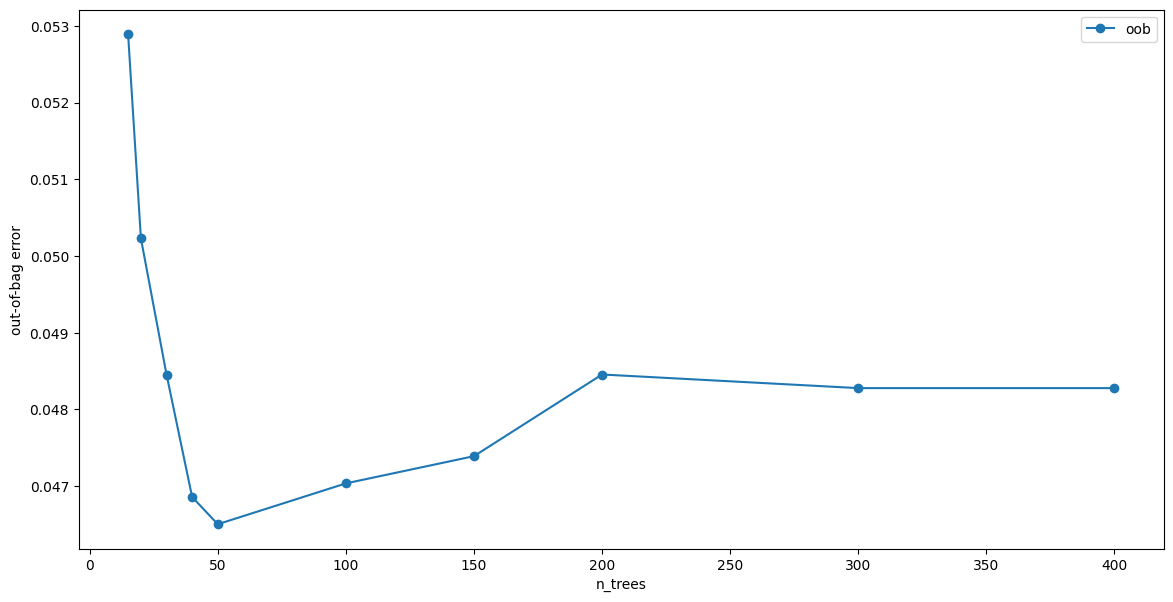

In [0]:
ax = rf_oob_df.plot(marker='o', figsize=(14, 7))
ax.set(ylabel='out-of-bag error');

# we can see out of bag error was best around 40 which is around where our gridsearchcv found (31)

In [0]:
from sklearn.ensemble import ExtraTreesClassifier

In [0]:
# try extra tree classifier to compare to regular random forest
EF = ExtraTreesClassifier(oob_score=True, 
                          random_state=42, 
                          warm_start=True,
                          bootstrap=True,
                          n_jobs=-1,
                         max_depth = 13, max_features = 'sqrt')

oob_list = list()

for n_trees in [15, 20, 30, 40, 50, 100, 150, 200, 300, 400]:
    
    EF.set_params(n_estimators=n_trees)
    EF.fit(x_v4train, y_v4train)

    oob_error = 1 - EF.oob_score_
    oob_list.append(pd.Series({'n_trees': n_trees, 'oob': oob_error}))

et_oob_df = pd.concat(oob_list, axis=1).T.set_index('n_trees')

et_oob_df

/databricks/python/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:586: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/databricks/python/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:586: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,oob
n_trees,
15.0,0.065318
20.0,0.059993
30.0,0.055378
40.0,0.051651
50.0,0.050941
100.0,0.048456
150.0,0.045793
200.0,0.045793
300.0,0.047036


In [0]:
oob_df = pd.concat([rf_oob_df.rename(columns={'oob':'RandomForest'}),
                    et_oob_df.rename(columns={'oob':'ExtraTrees'})], axis=1)

oob_df

,RandomForest,ExtraTrees
n_trees,,
15.0,0.052893,0.065318
20.0,0.050231,0.059993
30.0,0.048456,0.055378
40.0,0.046858,0.051651
50.0,0.046503,0.050941
100.0,0.047036,0.048456
150.0,0.047391,0.045793
200.0,0.048456,0.045793
300.0,0.048278,0.047036


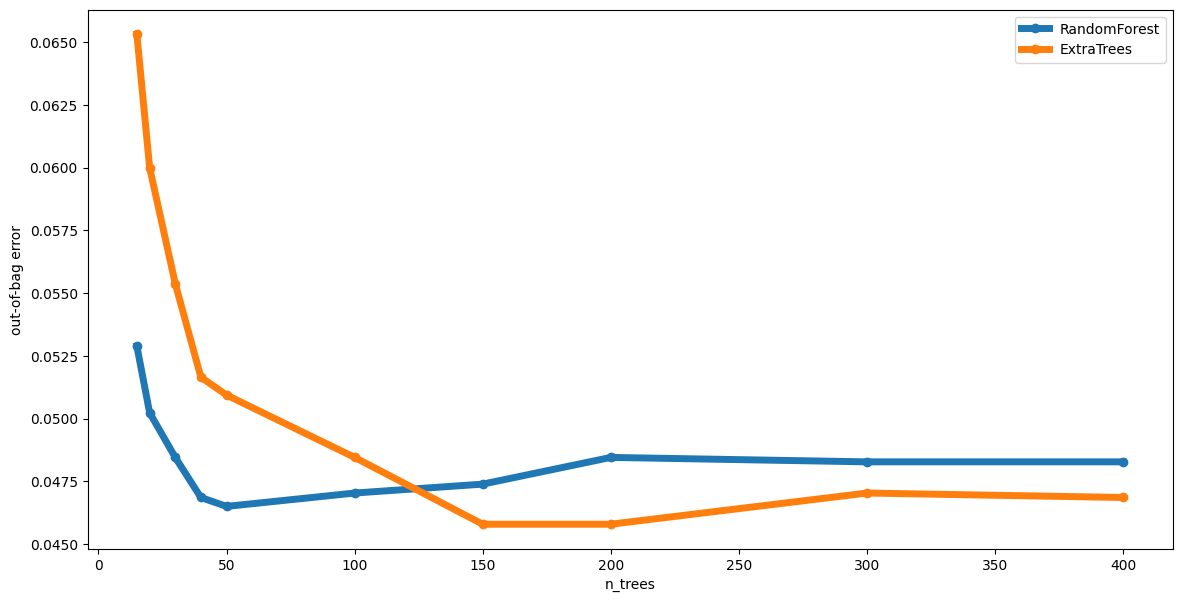

In [0]:
ax = oob_df.plot(marker='o', figsize=(14, 7), linewidth=5)
ax.set(ylabel='out-of-bag error');

# out of bag error is different at different points for RandomForest vs. Extra Trees but it looks like extra trees actually 
# wins the best out of bag error at around 150 trees

In [0]:
EF = ExtraTreesClassifier(oob_score=True, 
                          random_state=42, 
                          warm_start=True,
                          bootstrap=True,
                          n_jobs=-1,
                         max_depth = 11, max_features = 'sqrt', n_estimators = 21)

In [0]:
EF.fit(x_v4train, y_v4train)
EF_preds = EF.predict(x_v4test)

/databricks/python/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:586: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


In [0]:
EF_train_score = EF.score(x_v4train, y_v4train)
EF_test_score = EF.score(x_v4test, y_v4test)

print(EF.score(x_v4train, y_v4train))
print(EF.score(x_v4test, y_v4test))

0.9614838480653177
0.9552874378992193


In [0]:
# lets try and find the lowest overfitting gap without underfitting using GridSearchCV and the below algorithm

EF_best = ExtraTreesClassifier(warm_start=True,
                          bootstrap=True,
                          n_jobs=-1)

In [0]:
param_grid = {'n_estimators': [2*n+1 for n in range(30)],
              'max_depth' : [2*n+1 for n in range(10)],
              'max_features' : ["sqrt", "log2"]
             }

In [0]:
# method to find lowest overfitting gap (for extra trees)
# with the lowest possible test score being: best test score - 0.005 
# so we can avoid low train scores for underfitting

search = GridSearchCV(EF_best, param_grid, cv=3, return_train_score=True)
search.fit(x_v4train, y_v4train)

results_bag = pd.DataFrame(search.cv_results_)
results_bag["gap"] = results_bag["mean_train_score"] - results_bag["mean_test_score"]

best_test = results_bag["mean_test_score"].max()

filtered = results_bag[
    results_bag["mean_test_score"] >= best_test - 0.005
]

best_gap_model = filtered.sort_values("gap").iloc[0]
best_gap_model

mean_fit_time                                                  0.067597
std_fit_time                                                   0.004897
mean_score_time                                                0.014572
std_score_time                                                 0.000873
param_max_depth                                                       9
param_max_features                                                 sqrt
param_n_estimators                                                   41
params                {'max_depth': 9, 'max_features': 'sqrt', 'n_es...
split0_test_score                                              0.947284
split1_test_score                                              0.952609
split2_test_score                                              0.949414
mean_test_score                                                0.949769
std_test_score                                                 0.002188
rank_test_score                                                 

In [0]:
# best parameters found was max_depth = 9, max_features = 'log2', n_estimators = 37

EF_test = ExtraTreesClassifier(warm_start=True,
                          bootstrap=True,
                          n_jobs=-1,
                         max_depth = 9, max_features = 'log2', n_estimators = 37)

EF_test.fit(x_v4train, y_v4train)

EF_best_train_score = EF_test.score(x_v4train, y_v4train)
EF_best_test_score = EF_test.score(x_v4test, y_v4test)

print(EF_test.score(x_v4train, y_v4train))
print(EF_test.score(x_v4test, y_v4test))

0.9574014909478168
0.9524485450674237


In [0]:
EF_test_preds = EF_test.predict(x_v4test)

In [0]:
Randomforest_table = pd.DataFrame(
    [
        ["(max_depth = None, min_samples_split = 2, min_samples_leaf = 1, max_features = None)", DTC_bad_train_score, DTC_bad_test_score],
        ["(n_estimators = 21)", Bag_train_score, Bag_test_score],
        ["(n_estimators = 21, max_depth = 11, max_features = sqrt)", RFC_train_score, RFC_test_score],
        ["(n_estimators = 21, max_depth = 11, max_features = sqrt)", EF_train_score, EF_test_score],
        ["(n_estimators = 37, max_depth = 9, max_features = log2)", EF_best_train_score, EF_best_test_score]
    ],
    columns = ["Parameters", "Train score", "Test score",],
    index = ["Decision Tree", 
             "Bagging",
             "RandomForest",
             "Extra Trees",
             "Extra Trees + GridSearchCV algorithm"]
)

Randomforest_table["Overfit gap"] = (
    Randomforest_table["Train score"] - Randomforest_table["Test score"]
)


display(Markdown("##### Decision Tree vs. Bagging vs. Random Forest vs. Extra Trees Performance Comparison"))


display(
    Randomforest_table.style
    .format({"Overfit gap": "{:.4f}"})
    .set_properties(**{"white-space": "normal"})
     .highlight_min(subset=["Overfit gap"], props="font-weight: bold;")
)


##### Decision Tree vs. Bagging vs. Random Forest vs. Extra Trees Performance Comparison

,Parameters,Train score,Test score,Overfit gap
Decision Tree,"(max_depth = None, min_samples_split = 2, min_samples_leaf = 1, max_features = None)",0.999290,0.931157,0.0681
Bagging,(n_estimators = 21),0.998225,0.944642,0.0536
RandomForest,"(n_estimators = 21, max_depth = 11, max_features = sqrt)",0.967696,0.952449,0.0152
Extra Trees,"(n_estimators = 21, max_depth = 11, max_features = sqrt)",0.961484,0.955287,0.0062
Extra Trees + GridSearchCV algorithm,"(n_estimators = 37, max_depth = 9, max_features = log2)",0.957401,0.952449,0.0050


In [0]:
# we can see the overfitting gap is biggest with just regular decision trees
# then we add bagging and the overfitting gap reduces
# then we add random forest and the overfitting gap reduces even further
# then we add extra trees and the overfit gap reduces even further
# then we use GridSearchCV plus a homemade algorithm to find the best parameters to minimize overfitting gap and we reduce it even further

In [0]:
# now lets do some visualization of the least overfit model

In [0]:
from sklearn.metrics import confusion_matrix

In [0]:
cm_extratrees = confusion_matrix(y_v4test, EF_test_preds, normalize = 'true')

In [0]:
from sklearn.metrics import ConfusionMatrixDisplay

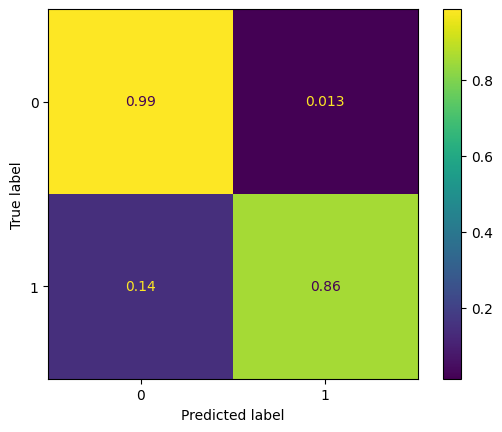

In [0]:
cm_plot_extratrees = ConfusionMatrixDisplay(confusion_matrix = cm_extratrees, display_labels = EF_test.classes_)
cm_plot_extratrees.plot()

In [0]:
# very good at predicting class 0, slightly worse at predicing class 1
# this makes sense because the classes are imbalanced
# i.e.
# 0 = 5174
# 1 = 1869

In [0]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

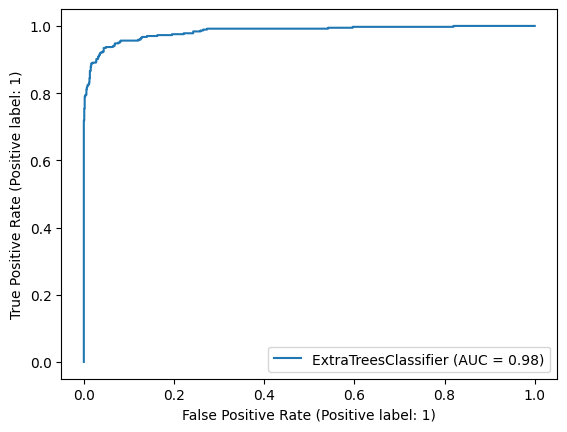

In [0]:
RocCurveDisplay.from_estimator(EF_test, x_v4test, y_v4test)

# ROC curve
# the model separates the two classes very well, achieving an AUC of about 0.98, meaning it correctly ranks positive cases higher 

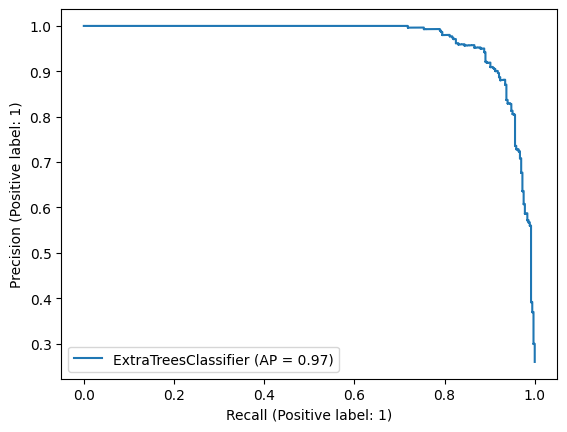

In [0]:
PrecisionRecallDisplay.from_estimator(EF_test, x_v4test, y_v4test)

# Precision-recall plot 
# The model maintains very high precision across most recall levels, with an average precision of about 0.96, indicating it correctly 
# identifies positive cases with very few false positives

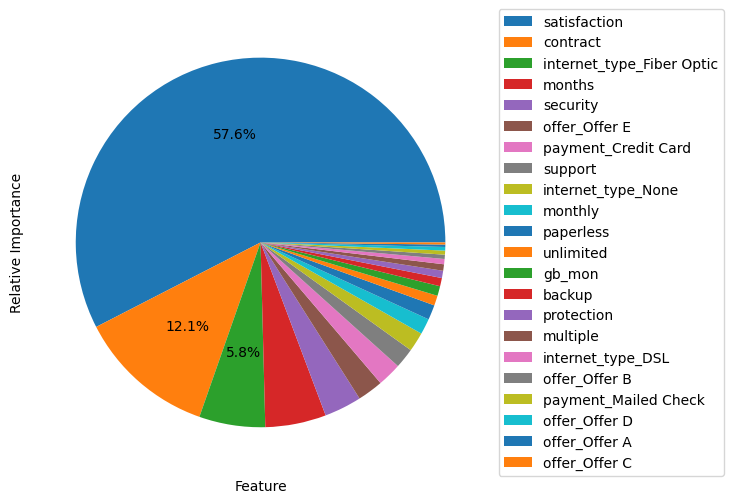

In [0]:
feature_imp = pd.Series(EF_test.feature_importances_, index=x_v4train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
ax.pie(feature_imp, labels=None, autopct=lambda pct: '{:1.1f}%'.format(pct) if pct > 5.5 else '')
ax.set(ylabel='Relative Importance')
ax.set(xlabel='Feature')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),labels=feature_imp.index)

plt.show()

In [0]:
# looks like the top 3 important features are satisfaction, contract, and months in that order

In [0]:
# now lets try boosting namely adaboost

In [0]:
data = spark.table(
    "churn_project_databricks.default.churndata_processed"
).toPandas()

In [0]:
x_v5 = data.drop("churn_value", axis = 1)
y_v5 = data["churn_value"]

In [0]:
x_v5train, x_v5test, y_v5train, y_v5test = train_test_split(x_v5, y_v5, test_size = 0.2, random_state = 123)

In [0]:
from sklearn.ensemble import AdaBoostClassifier

In [0]:
ada = AdaBoostClassifier(n_estimators = 5, random_state = 123)

In [0]:
ada.fit(x_v5train, y_v5train)
ada_preds = ada.predict(x_v5test)

In [0]:
ada_train_score = ada.score(x_v5train, y_v5train)
ada_test_score = ada.score(x_v5test, y_v5test)

print(ada.score(x_v5train, y_v5train))
print(ada.score(x_v5test, y_v5test))

# quite impressive scores with test score being greater than train score

0.9426695065672701
0.950319375443577


In [0]:
ada.base_estimator_

DecisionTreeClassifier(max_depth=1)

In [0]:
ada.estimators_

# shows h1(x), h2(x), h3(x), h4(x), h5(x) - because n_estimators = 5

[DecisionTreeClassifier(max_depth=1, random_state=843828734),
 DecisionTreeClassifier(max_depth=1, random_state=914636141),
 DecisionTreeClassifier(max_depth=1, random_state=1228959102),
 DecisionTreeClassifier(max_depth=1, random_state=1840268610),
 DecisionTreeClassifier(max_depth=1, random_state=974319580)]

In [0]:
import warnings

In [0]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    for i, model in enumerate(ada.estimators_):
        print(f"Estimator {i+1}:")
        print(model.score(x_v5train, y_v5train))
        print(model.score(x_v5test, y_v5test))  
        print()

# we can see the decision stumps are all over the place so we are going to be iterating on them

Estimator 1:
0.9382321618743344
0.9425124201561391

Estimator 2:
0.6869009584664537
0.6650106458481192

Estimator 3:
0.4708910188143415
0.4577714691270405

Estimator 4:
0.6893858714944977
0.7026259758694109

Estimator 5:
0.5875044373446929
0.5826827537260468



In [0]:
# lets try and get highest test accuracy with gridsearchcv

ada_grid = AdaBoostClassifier()

param_grid = {'learning_rate': [0.1*(n+1) for n in range(10)],
              # this is 0.1, 0.2, ... , 0.9
             'n_estimators' : [10*n+1 for n in range(11)]
              # this is 1, 21, 31, ... , 101
             }   

In [0]:
# lets find the best test score with gridsearchcv

search = GridSearchCV(estimator = ada_grid, param_grid = param_grid, scoring = 'accuracy')
search.fit(x_v5train, y_v5train)
print(search.best_score_)
print(search.best_params_)

0.9520755680448101
{'learning_rate': 0.7000000000000001, 'n_estimators': 21}


In [0]:
# the best learning_rate was 0.8 and the best n_estimators was 71

ada_grid_train_score = search.best_estimator_.score(x_v5train, y_v5train)
ada_grid_test_score = search.best_estimator_.score(x_v5test, y_v5test)

print(search.best_estimator_.score(x_v5train, y_v5train))
print(search.best_estimator_.score(x_v5test, y_v5test))

# great test score and great generalization to new data

0.9524316648917288
0.9538679914833215


In [0]:
ada_grid_preds = search.best_estimator_.predict(x_v5test)

In [0]:
# algorithm to plot train and test score accuracy vs. no of estimators for adaboost
# credits to Joseph Santarcangelo

def get_accuracy_bag(X,y,title,times=20,xlabel='Number Estimators',Learning_rate_=[0.2,0.4,0.6,1]):

    lines_array=['solid','--', '-.', ':']

    N_estimators=[n for n in range(1,100)]
    
    times=20
    train_acc=np.zeros((times,len(Learning_rate_),len(N_estimators)))
    test_acc=np.zeros((times,len(Learning_rate_),len(N_estimators)))


    for n in tqdm(range(times)):
        X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3)
        for n_estimators in N_estimators:
            for j,lr in enumerate(Learning_rate_):


                model = AdaBoostClassifier(n_estimators=n_estimators+1,random_state=0,learning_rate=lr)


                model.fit(X_train,y_train)



                Accuracy=get_accuracy(X_train, X_test, y_train, y_test,  model)



                train_acc[n,j,n_estimators-1]=Accuracy['train Accuracy']
                test_acc[n,j,n_estimators-1]=Accuracy['test Accuracy']




    fig, ax1 = plt.subplots()
    mean_test=test_acc.mean(axis=0)
    mean_train=train_acc.mean(axis=0)
    ax2 = ax1.twinx()

    for j,(lr,line) in enumerate(zip(Learning_rate_,lines_array)): 

        ax1.plot(mean_train[j,:],linestyle = line,color='b',label="Learning rate "+str(lr))
        ax2.plot(mean_test[j,:],linestyle = line, color='r',label=str(lr))

    ax1.set_ylabel('Training accuracy',color='b')
    ax1.set_xlabel('No of estimators')
    ax1.legend()
    ax2.set_ylabel('Testing accuracy', color='r')
    ax2.legend()
    plt.show()

100%|██████████| 20/20 [08:39<00:00, 25.98s/it]


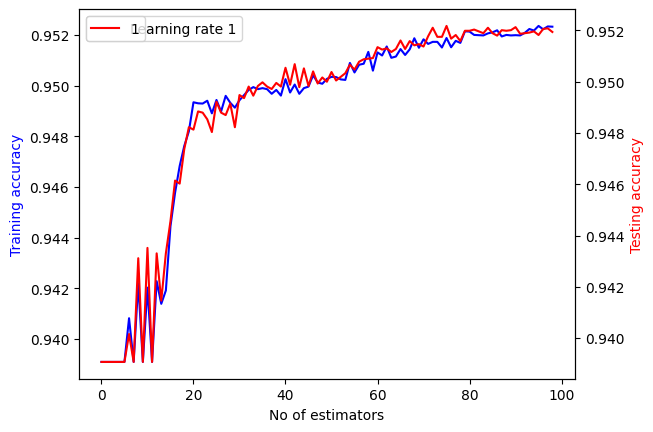

In [0]:
get_accuracy_bag(x_v5, y_v5, Learning_rate_ = [1], times = 20, xlabel = "Number of Estimators", title = "Train and test accuracy for weak classifiers")

In [0]:
# we can see here that as we add more estimators both the train and test go up
# with small data sets and large data sets boosting behaves differently
# for a small data set models easily overfit and training increases rapidly while testing scores decrease rapidly
# for a large data set models more estimators actually help with both train and test scores increasing

In [0]:
ada_custom_1 = AdaBoostClassifier(n_estimators = 100, learning_rate = 0.7, random_state = 123)

In [0]:
ada_custom_1.fit(x_v5train, y_v5train)
ada_custom_1_preds = ada_custom_1.predict(x_v5test)

In [0]:
ada_custom_1_train_score = ada_custom_1.score(x_v5train, y_v5train)
ada_custom_1_test_score = ada_custom_1.score(x_v5test, y_v5test)

print(ada_custom_1.score(x_v5train, y_v5train))
print(ada_custom_1.score(x_v5test, y_v5test))

# this is way smaller of an overfitting gap

0.9547390841320553
0.9538679914833215


100%|██████████| 20/20 [34:21<00:00, 103.08s/it]


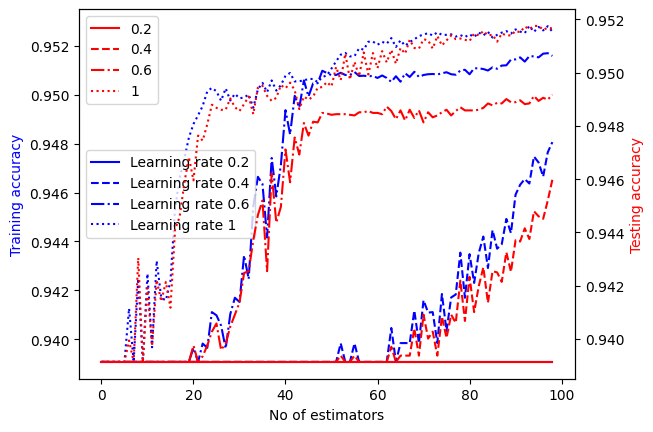

In [0]:
# lets see what happens to train and test scores with a range of learning rates [0.2, 0.4, 0.6, 1]

get_accuracy_bag(x_v5, y_v5, Learning_rate_ = [0.2, 0.4, 0.6, 1], times = 20, xlabel = "Number of Estimators", title = "Train and test accuracy for weak classifiers")

In [0]:
# it seems like higher learning rates reach their final accuracy with fewer estimators 
# and it takes longer and longer with lower learning rates 

In [0]:
# we can do adaboost with other base estimators as well such as SVM (support vector machine)

base_estimator = SVC(kernel = 'rbf', gamma = 1)
base_estimator.fit(x_v5train, y_v5train)

print(base_estimator.score(x_v5train, y_v5train))
print(base_estimator.score(x_v5test, y_v5test))

# lower test accuracy and overfit then decision tree base estimator

0.9703585374511892
0.9311568488289567


In [0]:
ada_SVC = AdaBoostClassifier(n_estimators = 5, base_estimator = base_estimator, learning_rate = 1, algorithm = "SAMME")
ada_SVC.fit(x_v5train, y_v5train)

AdaBoostClassifier(algorithm='SAMME', base_estimator=SVC(gamma=1),
                   learning_rate=1, n_estimators=5)

In [0]:
ada_SVC_train_score = ada_SVC.score(x_v5train, y_v5train)
ada_SVC_test_score = ada_SVC.score(x_v5test, y_v5test)

print(ada_SVC.score(x_v5train, y_v5train))
print(ada_SVC.score(x_v5test, y_v5test))

# does significantly worse as SVC than decision trees

0.7332268370607029
0.7402413058907026


In [0]:
adaboost_table = pd.DataFrame(
    [
        ["(estimator = SVC(kernel = 'rbf', gamma = 1), n_estimators = 5, learning_rate = 1", ada_SVC_train_score, ada_SVC_test_score],
        ["(estimator = DecisionTreeClassifier(), n_estimators = 5, learning_rate = 1)", ada_train_score, ada_test_score],
        ["(estimator = DecisionTreeClassifier(), n_estimators = 71, learning_rate = 0.8)", ada_grid_train_score, ada_grid_test_score]
    ],
    columns = ["Parameters", "Train score", "Test score",],
    index = ["SVC base estimator", 
             "Decision Tree base estimator",
             "Decision Tree base estimator + GridSearchCV"]
)


display(Markdown("##### AdaBoost: SVC vs. Decision Tree Performance Comparison"))

display(
    adaboost_table.style
    .set_properties(**{"white-space": "normal"})
     .highlight_max(subset=["Test score"], props="font-weight: bold;")
)


##### AdaBoost: SVC vs. Decision Tree Performance Comparison

,Parameters,Train score,Test score
SVC base estimator,"(estimator = SVC(kernel = 'rbf', gamma = 1), n_estimators = 5, learning_rate = 1",0.733227,0.740241
Decision Tree base estimator,"(estimator = DecisionTreeClassifier(), n_estimators = 5, learning_rate = 1)",0.942670,0.950319
Decision Tree base estimator + GridSearchCV,"(estimator = DecisionTreeClassifier(), n_estimators = 71, learning_rate = 0.8)",0.952432,0.953868


In [0]:
# we compared SVC base estimator which had a bad test score with decision tree which had quite a good test score
# then we maximized the decision tree test score with gridsearchCV which had a great score and great generalization

In [0]:
from sklearn.metrics import roc_auc_score

In [0]:
# Decision Tree base estimator + GridSearchCV precision, recall, fscores

ada_grid_precision, ada_grid_recall, ada_grid_fscore, ada_grid_support = precision_recall_fscore_support(y_v5test, 
                                                                            ada_grid_preds, beta = 5, pos_label = 1, average = 'binary')

ada_grid_auc = roc_auc_score(y_v5test, ada_grid_preds)

print(f"precision is: {ada_grid_precision:.2f}")
print(f"recall is: {ada_grid_recall:.2f}")
print(f"fscore is: {ada_grid_fscore:.2f}")
print(f"auc is: {ada_grid_auc:.2f}")

precision is: 0.94
recall is: 0.88
fscore is: 0.88
auc is: 0.93


In [0]:
# lets explore gradient boost namely XGBoost

In [0]:
data = spark.table(
    "churn_project_databricks.default.churndata_processed"
).toPandas()

In [0]:
x_v6 = data.drop("churn_value", axis = 1)
y_v6 = data["churn_value"]

In [0]:
x_v6train, x_v6test, y_v6train, y_v6test = train_test_split(x_v6, y_v6, test_size = 0.2, random_state = 123)

In [0]:
# install xgboost for azure ML

import sys

!{sys.executable} -m pip install xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 12.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 6.7 MB/s eta 0:00:00

[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [0]:
from xgboost import XGBClassifier

In [0]:
xgboost = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.1, n_estimators = 5, eval_metric = 'logloss')

In [0]:
xgboost.fit(x_v6train, y_v6train)
xgboost_preds = xgboost.predict(x_v6test)
xgboost_preds

array([0, 1, 0, ..., 0, 0, 0])

In [0]:
xgboost_train_score = xgboost.score(x_v6train, y_v6train)
xgboost_test_score = xgboost.score(x_v6test, y_v6test)

print(xgboost.score(x_v6train, y_v6train))
print(xgboost.score(x_v6test, y_v6test))

# quite impressive scores with test score being greater than train score

0.9382321618743344
0.9425124201561391


In [0]:
xgboost_custom1 = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.3, n_estimators = 5, eval_metric = 'logloss')
xgboost_custom1.fit(x_v6train, y_v6train)
xgboost_custom1_preds = xgboost_custom1.predict(x_v6test)

# learning_rate = 0.3 vs 0.1

In [0]:
xgboost_custom1_train_score = xgboost_custom1.score(x_v6train, y_v6train)
xgboost_custom1_test_score = xgboost_custom1.score(x_v6test, y_v6test)

print(xgboost_custom1.score(x_v6train, y_v6train))
print(xgboost_custom1.score(x_v6test, y_v6test))

# slightly more overfit but more accurate on the test score as expected

0.9547390841320553
0.9517388218594748


In [0]:
xgboost_custom2 = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.3, n_estimators = 100, eval_metric = 'logloss')
xgboost_custom2.fit(x_v6train, y_v6train)
xgboost_custom2_preds = xgboost_custom2.predict(x_v6test)

# learning_rate = 0.3 vs 0.1
# n_estimators = 100 vs 5

In [0]:
xgboost_custom2_train_score = xgboost_custom2.score(x_v6train, y_v6train)
xgboost_custom2_test_score = xgboost_custom2.score(x_v6test, y_v6test)

print(xgboost_custom2.score(x_v6train, y_v6train))
print(xgboost_custom2.score(x_v6test, y_v6test))

# way way more overfit but as expected because of n_estimators being very high

0.9934327298544551
0.9446415897799858


In [0]:
objective = 'binary:logistic'

In [0]:
# algorithm by Joseph Santarcangelo to calculate and plot the average accuracy of different learning rates on training and test data

def get_accuracy_boost(X,y,title,times=20,xlabel='Number Estimators',Learning_rate_=[0.2,0.4,0.6,1], n_est = 100):

    lines_array=['solid','--', '-.', ':']

    N_estimators=[n*2 for n in range(1,n_est//2)]
    
    train_acc=np.zeros((times,len(Learning_rate_),len(N_estimators)))
    test_acc=np.zeros((times,len(Learning_rate_),len(N_estimators)))


    
    for n in tqdm(range(times)):
        X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3)
        for n_estimators in N_estimators:
            for j,lr in enumerate(Learning_rate_):


                model = XGBClassifier(objective=objective,learning_rate=lr,n_estimators=n_estimators,eval_metric='logloss')


                model.fit(X_train,y_train)



                Accuracy=get_accuracy(X_train, X_test, y_train, y_test,  model)



                train_acc[n,j,(n_estimators//2)-1]=Accuracy['train Accuracy']
                test_acc[n,j,(n_estimators//2)-1]=Accuracy['test Accuracy']
    



    fig, ax1 = plt.subplots()
    mean_test=test_acc.mean(axis=0)
    mean_train=train_acc.mean(axis=0)
    ax2 = ax1.twinx()

    for j,(lr,line) in enumerate(zip(Learning_rate_,lines_array)): 

        ax1.plot(mean_train[j,:],linestyle = line,color='b',label="Learning rate "+str(lr))
        ax2.plot(mean_test[j,:],linestyle = line, color='r',label=str(lr))

    ax1.set_ylabel('Training accuracy',color='b')
    ax1.legend()
    ax2.set_ylabel('Testing accuracy', color='r')
    ax2.legend()
    ax1.set_xlabel(xlabel)
    plt.show()

100%|██████████| 10/10 [00:05<00:00,  1.79it/s]


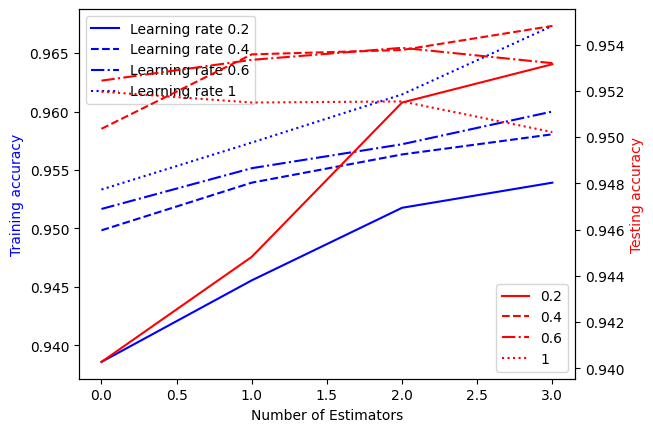

In [0]:
get_accuracy_boost(x_v6, y_v6, title = "Training and test accuracy vs. number of estimators", times = 10, xlabel = "Number of Estimators", 
n_est = 10)

In [0]:
# here we can see that the training accuracy increases as the number of estimators increase for all learning rates 
# for the testing accuracy, the accuracy increases as the number of estimators increase initially but then flatten
# higher learning rates reach high accuracy with fewer number of estimators
# the best test accuracy seems to be for learning rate 0.6-1 and estimators 2-3 as even though the testing accuracy flattens, 
# the training accuracy continues increasing

# here we can see that for learning rate = 1, as the number of estimators go up, the test accuracy actually decreases and the training
# accuracy increases causing overfitting. this is expected

In [0]:
# now lets try eval_metric = 'error'

eval_set = [(x_v6test, y_v6test)]

xgboost_custom3 = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.3, n_estimators = 5, eval_metric = 'error')
xgboost_custom3.fit(x_v6train, y_v6train, eval_set = eval_set)
xgboost_custom3_preds = xgboost_custom3.predict(x_v6test)

# use learning rate = 0.3 and n_estimators = 5 to compare against the so far best mlogless model. this is to make the results relevant

[0]	validation_0-error:0.05749
[1]	validation_0-error:0.05749
[2]	validation_0-error:0.04968
[3]	validation_0-error:0.04755
[4]	validation_0-error:0.04826


In [0]:
xgboost_custom3_train_score = xgboost_custom3.score(x_v6train, y_v6train)
xgboost_custom3_test_score = xgboost_custom3.score(x_v6test, y_v6test)

print(xgboost_custom3.score(x_v6train, y_v6train))
print(xgboost_custom3.score(x_v6test, y_v6test))


0.9547390841320553
0.9517388218594748


In [0]:
xgboost_graph = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.3, n_estimators = 100, eval_metric = 'logloss')


eval_set = [(x_v6train, y_v6train), (x_v6test, y_v6test)]
xgboost_graph.fit(x_v6train, y_v6train, eval_set=eval_set,verbose=False)
results_graph=xgboost_graph.evals_result()

# lets graph the error for each number of estimator for n_estimators up to 100 and learning_rate = 0.3

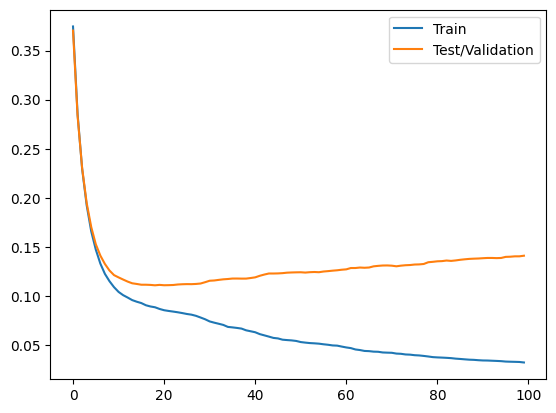

In [0]:
fig, ax = plt.subplots()
ax.plot( results_graph['validation_0']['logloss'], label='Train')
ax.plot( results_graph['validation_1']['logloss'], label='Test/Validation')
ax.legend()
plt.show()

# the test/validation line's error going down and then steadily going up is a sign of overfitting. we can stop this with early stopping
# at n_estimators = 20

In [0]:
eval_set = [(x_v6test, y_v6test)]

xgboost_custom4 = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.3, n_estimators = 100, eval_metric = 'logloss',
                               early_stopping_rounds = 10)
xgboost_custom4.fit(x_v6train, y_v6train, eval_set = eval_set)
xgboost_custom4_preds = xgboost_custom4.predict(x_v6test)

# we need to make n_estimators back to 100 so that early stopping rounds has some kind of effect here

[0]	validation_0-logloss:0.37029
[1]	validation_0-logloss:0.28370
[2]	validation_0-logloss:0.23041
[3]	validation_0-logloss:0.19479
[4]	validation_0-logloss:0.17042
[5]	validation_0-logloss:0.15293
[6]	validation_0-logloss:0.14138
[7]	validation_0-logloss:0.13285
[8]	validation_0-logloss:0.12623
[9]	validation_0-logloss:0.12151
[10]	validation_0-logloss:0.11917
[11]	validation_0-logloss:0.11700
[12]	validation_0-logloss:0.11491
[13]	validation_0-logloss:0.11318
[14]	validation_0-logloss:0.11250
[15]	validation_0-logloss:0.11173
[16]	validation_0-logloss:0.11172
[17]	validation_0-logloss:0.11154
[18]	validation_0-logloss:0.11114
[19]	validation_0-logloss:0.11156
[20]	validation_0-logloss:0.11120
[21]	validation_0-logloss:0.11129
[22]	validation_0-logloss:0.11145
[23]	validation_0-logloss:0.11196
[24]	validation_0-logloss:0.11222
[25]	validation_0-logloss:0.11235
[26]	validation_0-logloss:0.11230
[27]	validation_0-logloss:0.11252
[28]	validation_0-logloss:0.11295


In [0]:
xgboost_custom4_train_score = xgboost_custom4.score(x_v6train, y_v6train)
xgboost_custom4_test_score = xgboost_custom4.score(x_v6test, y_v6test)

print(xgboost_custom4.score(x_v6train, y_v6train))
print(xgboost_custom4.score(x_v6test, y_v6test))

# indeed this has a higher test accuracy and manageable overfitting amount than n_estimators = 100 and 5



0.9618388356407526
0.9552874378992193


In [0]:
eval_set = [(x_v6test, y_v6test)]

xgboost_custom5 = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.3, n_estimators = 100, eval_metric = 'logloss',
                               early_stopping_rounds = 10, max_depth = 3)
xgboost_custom5.fit(x_v6train, y_v6train, eval_set = eval_set)
xgboost_custom5_preds = xgboost_custom5.predict(x_v6test)

[0]	validation_0-logloss:0.38388
[1]	validation_0-logloss:0.29993
[2]	validation_0-logloss:0.24914
[3]	validation_0-logloss:0.21325
[4]	validation_0-logloss:0.18917
[5]	validation_0-logloss:0.17044
[6]	validation_0-logloss:0.15638
[7]	validation_0-logloss:0.14671
[8]	validation_0-logloss:0.13809
[9]	validation_0-logloss:0.13256
[10]	validation_0-logloss:0.12774
[11]	validation_0-logloss:0.12409
[12]	validation_0-logloss:0.12049
[13]	validation_0-logloss:0.11856
[14]	validation_0-logloss:0.11636
[15]	validation_0-logloss:0.11395
[16]	validation_0-logloss:0.11296
[17]	validation_0-logloss:0.11324
[18]	validation_0-logloss:0.11264
[19]	validation_0-logloss:0.11355
[20]	validation_0-logloss:0.11318
[21]	validation_0-logloss:0.11334
[22]	validation_0-logloss:0.11287
[23]	validation_0-logloss:0.11221
[24]	validation_0-logloss:0.11212
[25]	validation_0-logloss:0.11184
[26]	validation_0-logloss:0.11138
[27]	validation_0-logloss:0.11103
[28]	validation_0-logloss:0.11240
[29]	validation_0-loglos

In [0]:
xgboost_custom5_train_score = xgboost_custom5.score(x_v6train, y_v6train)
xgboost_custom5_test_score = xgboost_custom5.score(x_v6test, y_v6test)

print(xgboost_custom5.score(x_v6train, y_v6train))
print(xgboost_custom5.score(x_v6test, y_v6test))

# here lowering the max depth from 6 to 3 has very similar overfitting gaps so this means we werent overfitting much with max depth 6 


0.9597089101881434
0.9524485450674237


In [0]:
eval_set = [(x_v6test, y_v6test)]

xgboost_custom6 = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.3, n_estimators = 100, eval_metric = 'logloss',
                               early_stopping_rounds = 10, min_child_weight = 4)
xgboost_custom6.fit(x_v6train, y_v6train, eval_set = eval_set)
xgboost_custom6_preds = xgboost_custom6.predict(x_v6test)

[0]	validation_0-logloss:0.37029
[1]	validation_0-logloss:0.28370
[2]	validation_0-logloss:0.23043
[3]	validation_0-logloss:0.19454
[4]	validation_0-logloss:0.16993
[5]	validation_0-logloss:0.15277
[6]	validation_0-logloss:0.14197
[7]	validation_0-logloss:0.13339
[8]	validation_0-logloss:0.12691
[9]	validation_0-logloss:0.12176
[10]	validation_0-logloss:0.11947
[11]	validation_0-logloss:0.11706
[12]	validation_0-logloss:0.11541
[13]	validation_0-logloss:0.11403
[14]	validation_0-logloss:0.11328
[15]	validation_0-logloss:0.11272
[16]	validation_0-logloss:0.11334
[17]	validation_0-logloss:0.11363
[18]	validation_0-logloss:0.11323
[19]	validation_0-logloss:0.11276
[20]	validation_0-logloss:0.11189
[21]	validation_0-logloss:0.11236
[22]	validation_0-logloss:0.11247
[23]	validation_0-logloss:0.11265
[24]	validation_0-logloss:0.11492
[25]	validation_0-logloss:0.11552
[26]	validation_0-logloss:0.11647
[27]	validation_0-logloss:0.11647
[28]	validation_0-logloss:0.11663
[29]	validation_0-loglos

In [0]:
xgboost_custom6_train_score = xgboost_custom6.score(x_v6train, y_v6train)
xgboost_custom6_test_score = xgboost_custom6.score(x_v6test, y_v6test)

print(xgboost_custom6.score(x_v6train, y_v6train))
print(xgboost_custom6.score(x_v6test, y_v6test))

# here increasing the min_child_weight from 1 to 4 lowered test accuracy by making the model more constrained and thus that increased 
# the overfitting gap. so the min_child_weight of 1 was a better model for test accuracy

0.9639687610933617
0.950319375443577


In [0]:
eval_set = [(x_v6test, y_v6test)]

xgboost_custom7 = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.3, n_estimators = 100, eval_metric = 'logloss',
                               early_stopping_rounds = 10, gamma = 1, reg_lambda = 2, alpha = 1)
xgboost_custom7.fit(x_v6train, y_v6train, eval_set = eval_set)
xgboost_custom7_preds = xgboost_custom7.predict(x_v6test)

[0]	validation_0-logloss:0.37171
[1]	validation_0-logloss:0.28477
[2]	validation_0-logloss:0.23078
[3]	validation_0-logloss:0.19368
[4]	validation_0-logloss:0.17025
[5]	validation_0-logloss:0.15265
[6]	validation_0-logloss:0.14058
[7]	validation_0-logloss:0.13147
[8]	validation_0-logloss:0.12612
[9]	validation_0-logloss:0.12185
[10]	validation_0-logloss:0.11852
[11]	validation_0-logloss:0.11567
[12]	validation_0-logloss:0.11404
[13]	validation_0-logloss:0.11301
[14]	validation_0-logloss:0.11190
[15]	validation_0-logloss:0.11105
[16]	validation_0-logloss:0.11055
[17]	validation_0-logloss:0.10999
[18]	validation_0-logloss:0.11039
[19]	validation_0-logloss:0.11016
[20]	validation_0-logloss:0.10998
[21]	validation_0-logloss:0.10989
[22]	validation_0-logloss:0.10989
[23]	validation_0-logloss:0.10988
[24]	validation_0-logloss:0.10988
[25]	validation_0-logloss:0.10988
[26]	validation_0-logloss:0.10988
[27]	validation_0-logloss:0.10988
[28]	validation_0-logloss:0.10988
[29]	validation_0-loglos

In [0]:
xgboost_custom7_train_score = xgboost_custom7.score(x_v6train, y_v6train)
xgboost_custom7_test_score = xgboost_custom7.score(x_v6test, y_v6test)

print(xgboost_custom7.score(x_v6train, y_v6train))
print(xgboost_custom7.score(x_v6test, y_v6test))

# here increasing the gamma, reg_lambda, and alpha values lowered test accuracy by making the model more constrained and thus that 
# increased the overfitting gap. so the defaults (lower for everything) were a better model for test accuracy 

0.9598864039758609
0.950319375443577


In [0]:
xgboost_gridsearch = XGBClassifier(objective = 'binary:logistic', eval_metric = 'logloss')

eval_set = [(x_v6test, y_v6test)]
# lets set up gridsearch

In [0]:
param_grid = {
    'learning_rate': [0.1*(n+1) for n in range(5)],      
    'n_estimators': [2*n+1 for n in range(5)],           
    'early_stopping_rounds': [5, 10, 20],
    'gamma': [0, 0.1, 0.3, 0.5, 1],
    'reg_lambda': [0, 0.5, 1, 2, 5],
    'reg_alpha': [0, 0.1, 0.5, 1, 2]
}

In [0]:
search_xgboost = GridSearchCV(estimator = xgboost_gridsearch, param_grid = param_grid, scoring = 'neg_log_loss')
search_xgboost.fit(x_v6train, y_v6train, eval_set = eval_set, verbose = False)

GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=Non...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'early_stopping_rounds': [5, 10, 20],
                         'gamma': [0, 0.1, 0.3, 0.5, 1],
                         'learning_rate': [0.1, 0.2, 0.30000000000000004, 0.4,
                                           0.5],
                         'n_estimators': [1, 3, 5, 7, 9],
                         'reg_alpha': [0, 0.1, 0.5, 1, 2],
                         'reg_lambda': [0, 0.5, 1, 2, 5]},
             scoring='neg_log_loss')

In [0]:
search_xgboost.best_score_

-0.11125612508896672

In [0]:
search_xgboost.best_params_

# it looks like the best combination found was early stopping rounds = 5, gamma = 0 (default), learning_rate = 0.5, n_estimators = 9,
# reg_lambda = 0.5, reg_alpha = 0.1

{'early_stopping_rounds': 5,
 'gamma': 0,
 'learning_rate': 0.5,
 'n_estimators': 9,
 'reg_alpha': 0.1,
 'reg_lambda': 0.5}

In [0]:
xgboost_gridsearch_train_score = search_xgboost.best_estimator_.score(x_v6train, y_v6train)
xgboost_gridsearch_test_score = search_xgboost.best_estimator_.score(x_v6test, y_v6test)

print(search_xgboost.best_estimator_.score(x_v6train, y_v6train))
print(search_xgboost.best_estimator_.score(x_v6test, y_v6test))

# excellent test score and overfitting gap. the best so far

0.9598864039758609
0.9567068843151171


In [0]:
xgboost_table = pd.DataFrame(
    [
        ["""objective = 'binary:logistic', eval_metric = 'logloss', learning_rate = 0.1, n_estimators = 5, early_stopping_rounds = None, 
         gamma = 0, reg_lambda = 1, alpha = 0""", 
         xgboost_train_score, xgboost_test_score],
        ["""objective = 'binary:logistic', eval_metric = 'logloss', learning_rate = 0.3, n_estimators = 5, early_stopping_rounds = None,
         gamma = 0, reg_lambda = 1, alpha = 0""", 
         xgboost_custom1_train_score, xgboost_custom1_test_score],
        ["""objective = 'binary:logistic', eval_metric = 'logloss', learning_rate = 0.3, n_estimators = 100, early_stopping_rounds = None,
         gamma = 0, reg_lambda = 1, alpha = 0""", 
         xgboost_custom2_train_score, xgboost_custom2_test_score],
        ["""objective = 'binary:logistic', eval_metric = 'logloss', learning_rate = 0.3, n_estimators = 100, early_stopping_rounds = 10,
         gamma = 0, reg_lambda = 1, alpha = 0""", 
         xgboost_custom4_train_score, xgboost_custom4_test_score],
        ["""objective = 'binary:logistic', eval_metric = 'logloss', learning_rate = 0.5, n_estimators = 9, early_stopping_rounds = 5,
         gamma = 0, reg_lambda = 0.5, alpha = 0.1""", 
         xgboost_gridsearch_train_score, xgboost_gridsearch_test_score]
    ],
    columns = ["Parameters", "Train score", "Test score",],
    index = ["learning_rate = 0.1", 
             "learning_rate = 0.3",
             "learning_rate = 0.3, n_estimators = 100",
             "learning_rate = 0.3, n_estimators = 100, early_stopping_rounds = 10",
             "GridSearchCV"]
)

xgboost_table.index.name = "What We Changed"

display(Markdown("##### XGBoost: Parameters Performance Comparison"))

display(
    xgboost_table.style
    .set_properties(**{"white-space": "normal"})
     .highlight_max(subset=["Test score"], props="font-weight: bold;")
)


##### XGBoost: Parameters Performance Comparison

,Parameters,Train score,Test score
What We Changed,,,
learning_rate = 0.1,"objective = 'binary:logistic', eval_metric = 'logloss', learning_rate = 0.1, n_estimators = 5, early_stopping_rounds = None, gamma = 0, reg_lambda = 1, alpha = 0",0.938232,0.942512
learning_rate = 0.3,"objective = 'binary:logistic', eval_metric = 'logloss', learning_rate = 0.3, n_estimators = 5, early_stopping_rounds = None, gamma = 0, reg_lambda = 1, alpha = 0",0.954739,0.951739
"learning_rate = 0.3, n_estimators = 100","objective = 'binary:logistic', eval_metric = 'logloss', learning_rate = 0.3, n_estimators = 100, early_stopping_rounds = None, gamma = 0, reg_lambda = 1, alpha = 0",0.993433,0.944642
"learning_rate = 0.3, n_estimators = 100, early_stopping_rounds = 10","objective = 'binary:logistic', eval_metric = 'logloss', learning_rate = 0.3, n_estimators = 100, early_stopping_rounds = 10, gamma = 0, reg_lambda = 1, alpha = 0",0.961839,0.955287
GridSearchCV,"objective = 'binary:logistic', eval_metric = 'logloss', learning_rate = 0.5, n_estimators = 9, early_stopping_rounds = 5, gamma = 0, reg_lambda = 0.5, alpha = 0.1",0.959886,0.956707


In [0]:
# now lets look at stacking

In [0]:
data = spark.table(
    "churn_project_databricks.default.churndata_processed"
).toPandas()

In [0]:
x_v7 = data.drop("churn_value", axis = 1)
y_v7 = data["churn_value"]

x_v7train, x_v7test, y_v7train, y_v7test = train_test_split(x_v7, y_v7, test_size = 0.2, random_state = 123)

In [0]:
# create the models used for stacking

estimators_stacking = [
    ('SVM',SVC(random_state=42)),('KNN',KNeighborsClassifier()),('dt',DecisionTreeClassifier())
]
estimators_stacking

[('SVM', SVC(random_state=42)),
 ('KNN', KNeighborsClassifier()),
 ('dt', DecisionTreeClassifier())]

In [0]:
from sklearn.ensemble import StackingClassifier

In [0]:
stacking = StackingClassifier(estimators = estimators_stacking, final_estimator = LogisticRegression())

In [0]:
stacking.fit(x_v7train, y_v7train)
stacking_preds = stacking.predict(x_v7test)

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fc667c7bd00>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

In [0]:
stacking_train_score = stacking.score(x_v7train, y_v7train)
stacking_test_score = stacking.score(x_v7test, y_v7test)

print(stacking.score(x_v7train, y_v7train))
print(stacking.score(x_v7test, y_v7test))

# quite good results with high test accuracy and slightly overfit

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fc670f8c280>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

0.96201632942847
0.9588360539389638


In [0]:
# we use logisticregression instead of decision trees for one of the estimators

estimators_stacking_2 = [
    ('SVM',SVC(random_state=42)),('KNN',KNeighborsClassifier()),('lr',LogisticRegression())
]
estimators_stacking_2

[('SVM', SVC(random_state=42)),
 ('KNN', KNeighborsClassifier()),
 ('lr', LogisticRegression())]

In [0]:
# we use decision tree classifier instead of logistic regression for the final estimator

stacking_custom1 = StackingClassifier(estimators = estimators_stacking_2, final_estimator = DecisionTreeClassifier())
stacking_custom1.fit(x_v7train,y_v7train)
stacking_custom1_preds=stacking_custom1.predict(x_v7test)

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fc657ece710>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

In [0]:
stacking_custom1_train_score = stacking_custom1.score(x_v7train, y_v7train)
stacking_custom1_test_score = stacking_custom1.score(x_v7test, y_v7test)

print(stacking_custom1.score(x_v7train, y_v7train))
print(stacking_custom1.score(x_v7test, y_v7test))

# the test accuracy is lower here but slightly less overfit

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fc657ecd1b0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

0.9378771742988995
0.9347054648687012


In [0]:
estimators_stacking_3 = [
    ('SVM',SVC(random_state=42)),('KNN',KNeighborsClassifier()),('dt',DecisionTreeClassifier())
]
estimators_stacking_3

[('SVM', SVC(random_state=42)),
 ('KNN', KNeighborsClassifier()),
 ('dt', DecisionTreeClassifier())]

In [0]:
# we use the first stacking model we made wih the best results(decision tree classifier in estimator and logistic regression for final 
# estimator) and then we do gridsearchCV

stacking_gridsearch = StackingClassifier(estimators = estimators_stacking_3, final_estimator = LogisticRegression())

In [0]:
param_grid = {'dt__max_depth': [n for n in range(1, 11)],'dt__random_state':[0],'SVM__C':[0.01,0.1,1],'SVM__kernel':['linear', 'poly', 'rbf'],'KNN__n_neighbors':[1,4,8,9] }

In [0]:
search = GridSearchCV(estimator = stacking_gridsearch, param_grid = param_grid, scoring = 'accuracy')
search.fit(x_v7train, y_v7train)

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fc657eccb80>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

GridSearchCV(estimator=StackingClassifier(estimators=[('SVM',
                                                       SVC(random_state=42)),
                                                      ('KNN',
                                                       KNeighborsClassifier()),
                                                      ('dt',
                                                       DecisionTreeClassifier())],
                                          final_estimator=LogisticRegression()),
             param_grid={'KNN__n_neighbors': [1, 4, 8, 9],
                         'SVM__C': [0.01, 0.1, 1],
                         'SVM__kernel': ['linear', 'poly', 'rbf'],
                         'dt__max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'dt__random_state': [0]},
             scoring='accuracy')

In [0]:
search.best_score_

0.9547384480087502

In [0]:
search.best_params_

# best params for knn n_neighbors is 1
# for SVM c value is 0.1
# for SVM kernel is rbf
# for dt max depth is 2

{'KNN__n_neighbors': 1,
 'SVM__C': 0.1,
 'SVM__kernel': 'rbf',
 'dt__max_depth': 2,
 'dt__random_state': 0}

In [0]:
stacking_gridsearch_preds = search.best_estimator_.predict(x_v7test)

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fc657d96dd0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


In [0]:
stacking_gridsearch_train_score = search.best_estimator_.score(x_v7train, y_v7train)
stacking_gridsearch_test_score = search.best_estimator_.score(x_v7test, y_v7test)

print(search.best_estimator_.score(x_v7train, y_v7train))
print(search.best_estimator_.score(x_v7test, y_v7test))

# great test accuracy and even fixed overfitting

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fc657d96dd0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

0.9563365282215123


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fc657eccb80>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


0.9567068843151171


In [0]:
stacking_table = pd.DataFrame(
    [
        ["""estimators = Support Vector Machine (SVM), K-nearest-neighbors (KNN), Logistic Regression (lr), 
        final_estimator = Decision Tree Classifier (dt)""", 
         stacking_custom1_train_score, stacking_custom1_test_score],
        ["""estimators = Support Vector Machine (SVM), K-nearest-neighbors (KNN), Decision Tree Classifier (dt),
        final_estimator = Logistic Regression (lr)""", 
         stacking_train_score, stacking_test_score],
        ["""estimators = Support Vector Machine (SVM) with C value = 0.1 and kernel = rbf, K-nearest-neighbors (KNN) with n_neighbors = 1, 
        Decision Tree Classifier (dt) with max depth = 2,
        final_estimator = Logistic Regression (lr)""", 
         stacking_gridsearch_train_score, stacking_gridsearch_test_score],
    ],
    columns = ["Parameters", "Train score", "Test score",],
    index = ["final estimator = Decision Tree Classifier", 
             "final estimator = Logistic Regression",
             "GridSearchCV"]
)

stacking_table.index.name = "What We Changed"

display(Markdown("##### Stacking: Parameters Performance Comparison"))

display(
    stacking_table.style
    .set_properties(**{"white-space": "normal"})
     .highlight_max(subset=["Test score"], props="font-weight: bold;")
)


##### Stacking: Parameters Performance Comparison

,Parameters,Train score,Test score
What We Changed,,,
final estimator = Decision Tree Classifier,"estimators = Support Vector Machine (SVM), K-nearest-neighbors (KNN), Logistic Regression (lr), final_estimator = Decision Tree Classifier (dt)",0.937877,0.934705
final estimator = Logistic Regression,"estimators = Support Vector Machine (SVM), K-nearest-neighbors (KNN), Decision Tree Classifier (dt), final_estimator = Logistic Regression (lr)",0.962016,0.958836
GridSearchCV,"estimators = Support Vector Machine (SVM) with C value = 0.1 and kernel = rbf, K-nearest-neighbors (KNN) with n_neighbors = 1, Decision Tree Classifier (dt) with max depth = 2, final_estimator = Logistic Regression (lr)",0.956337,0.956707


In [0]:
# Stacking GridSearchCV precision, recall, fscores

stacking_precision, stacking_recall, stacking_fscore, stacking_support = precision_recall_fscore_support(y_v7test, 
                                                                            stacking_gridsearch_preds, beta = 5, pos_label = 1, average = 'binary')

stacking_auc = roc_auc_score(y_v7test, stacking_gridsearch_preds)

print(f"precision is: {stacking_precision:.2f}")
print(f"recall is: {stacking_recall:.2f}")
print(f"fscore is: {stacking_fscore:.2f}")
print(f"auc is: {stacking_auc:.2f}")

precision is: 0.96
recall is: 0.87
fscore is: 0.88
auc is: 0.93


In [0]:
# now lets look at model agnostic explanations
# namely permutation feature importance
# partial dependency plot (PDP)
# global surrogate model
# local surrogate model (LIME)

In [0]:
data = spark.table(
    "churn_project_databricks.default.churndata_processed"
).toPandas()

In [0]:
x_v8 = data.drop("churn_value", axis = 1)
y_v8 = data["churn_value"]

x_v8train, x_v8test, y_v8train, y_v8test = train_test_split(x_v8, y_v8, test_size = 0.2, random_state = 123)

In [0]:
# lets use random forest as our black box model. black box model is a model in which the combined behavior of the model becomes too 
black_box_model = RandomForestClassifier(random_state = 123, max_depth = 25, max_features = 10, n_estimators = 100, bootstrap = True)
black_box_model.fit(x_v8train, y_v8train)

RandomForestClassifier(max_depth=25, max_features=10, random_state=123)

In [0]:
black_box_model_preds = black_box_model.predict(x_v8test)

In [0]:
black_box_model_train_score = black_box_model.score(x_v8train, y_v8train)
black_box_model_test_score = black_box_model.score(x_v8test, y_v8test)

print(black_box_model.score(x_v8train, y_v8train))
print(black_box_model.score(x_v8test, y_v8test))

# good test accuracy but moderately overfit

0.9992900248491303
0.9474804826117814


In [0]:
# lets start with permutation feature importance to explain our black box model

from sklearn.inspection import permutation_importance

In [0]:
permutation_feature = permutation_importance(estimator=black_box_model, X=x_v8train, y=y_v8train, n_repeats = 5, random_state = 123,
                                                n_jobs = 2)

In [0]:
permutation_feature.importances.shape

(22, 5)

In [0]:
permutation_feature.importances

array([[0.02875399, 0.02839901, 0.02910898, 0.02839901, 0.02786652],
       [0.00496983, 0.0056798 , 0.00550231, 0.00550231, 0.00550231],
       [0.02200923, 0.02413916, 0.02413916, 0.02307419, 0.02413916],
       [0.02254171, 0.0227192 , 0.02307419, 0.02413916, 0.02254171],
       [0.00425985, 0.00461484, 0.00603479, 0.00425985, 0.00443734],
       [0.00248491, 0.00248491, 0.00301739, 0.00230742, 0.00195243],
       [0.00550231, 0.00621228, 0.0056798 , 0.00550231, 0.00514732],
       [0.00212993, 0.00230742, 0.00159744, 0.00088747, 0.00195243],
       [0.03035144, 0.0342563 , 0.03372382, 0.03656372, 0.03461129],
       [0.00905218, 0.00692226, 0.00727725, 0.0085197 , 0.00958466],
       [0.03904863, 0.03620873, 0.03975861, 0.03833866, 0.04100106],
       [0.31611644, 0.31877884, 0.32303869, 0.31966631, 0.31789137],
       [0.01579695, 0.01686191, 0.014377  , 0.01402201, 0.01526447],
       [0.00088747, 0.00106496, 0.00088747, 0.00070998, 0.00070998],
       [0.00106496, 0.00141995, 0.

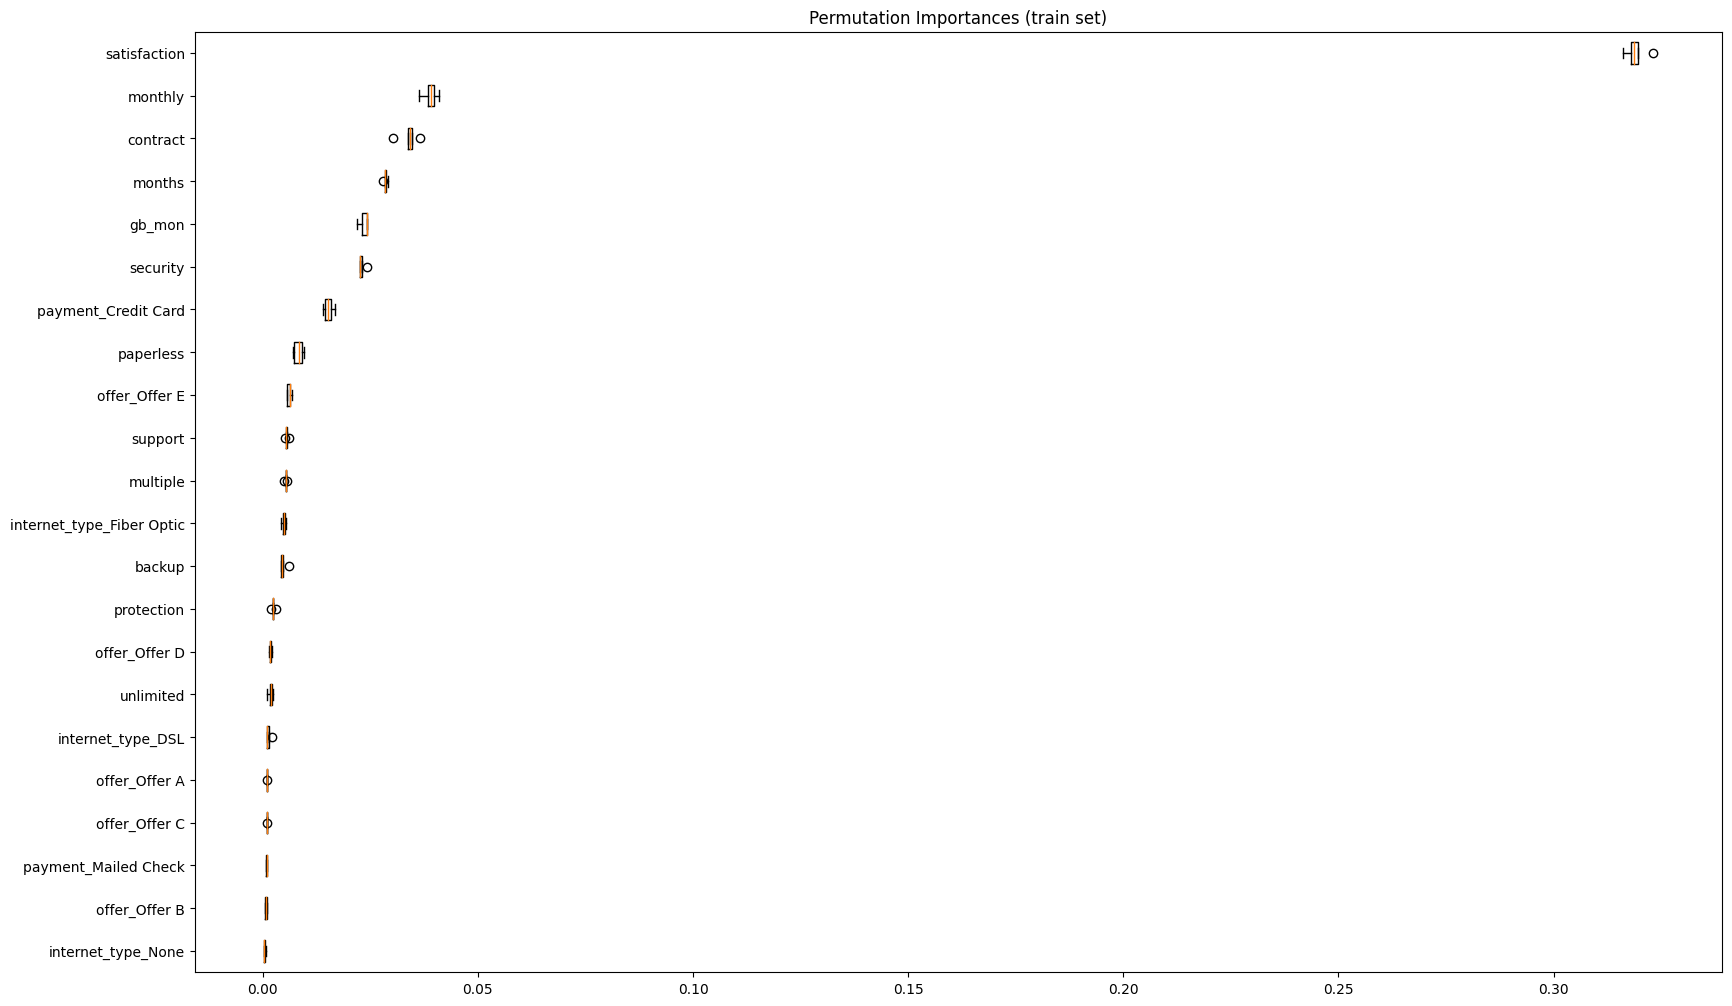

In [0]:
sorted_idx = permutation_feature.importances_mean.argsort()


fig, ax = plt.subplots()
fig.set_figwidth(16)
fig.set_figheight(10)
fig.tight_layout()
ax.boxplot(permutation_feature.importances[sorted_idx].T, vert=False, labels=x_v8train.columns[sorted_idx])
ax.set_title("Permutation Importances (train set)")
plt.show()

In [0]:
# satisfaction seems to be the most important feature by far followed by 
# monthly (monthly bill), 
# contract (month to month, 12 months, 24 months), 
# months (how long the customer has been with the company), and 
# gb_mon (gigabyte data usage per month)

In [0]:
# try n_repeats = 10

permutation_feature_custom1 = permutation_importance(estimator=black_box_model, X=x_v8train, y=y_v8train, n_repeats = 10, 
                                                        random_state = 123, n_jobs = 2)

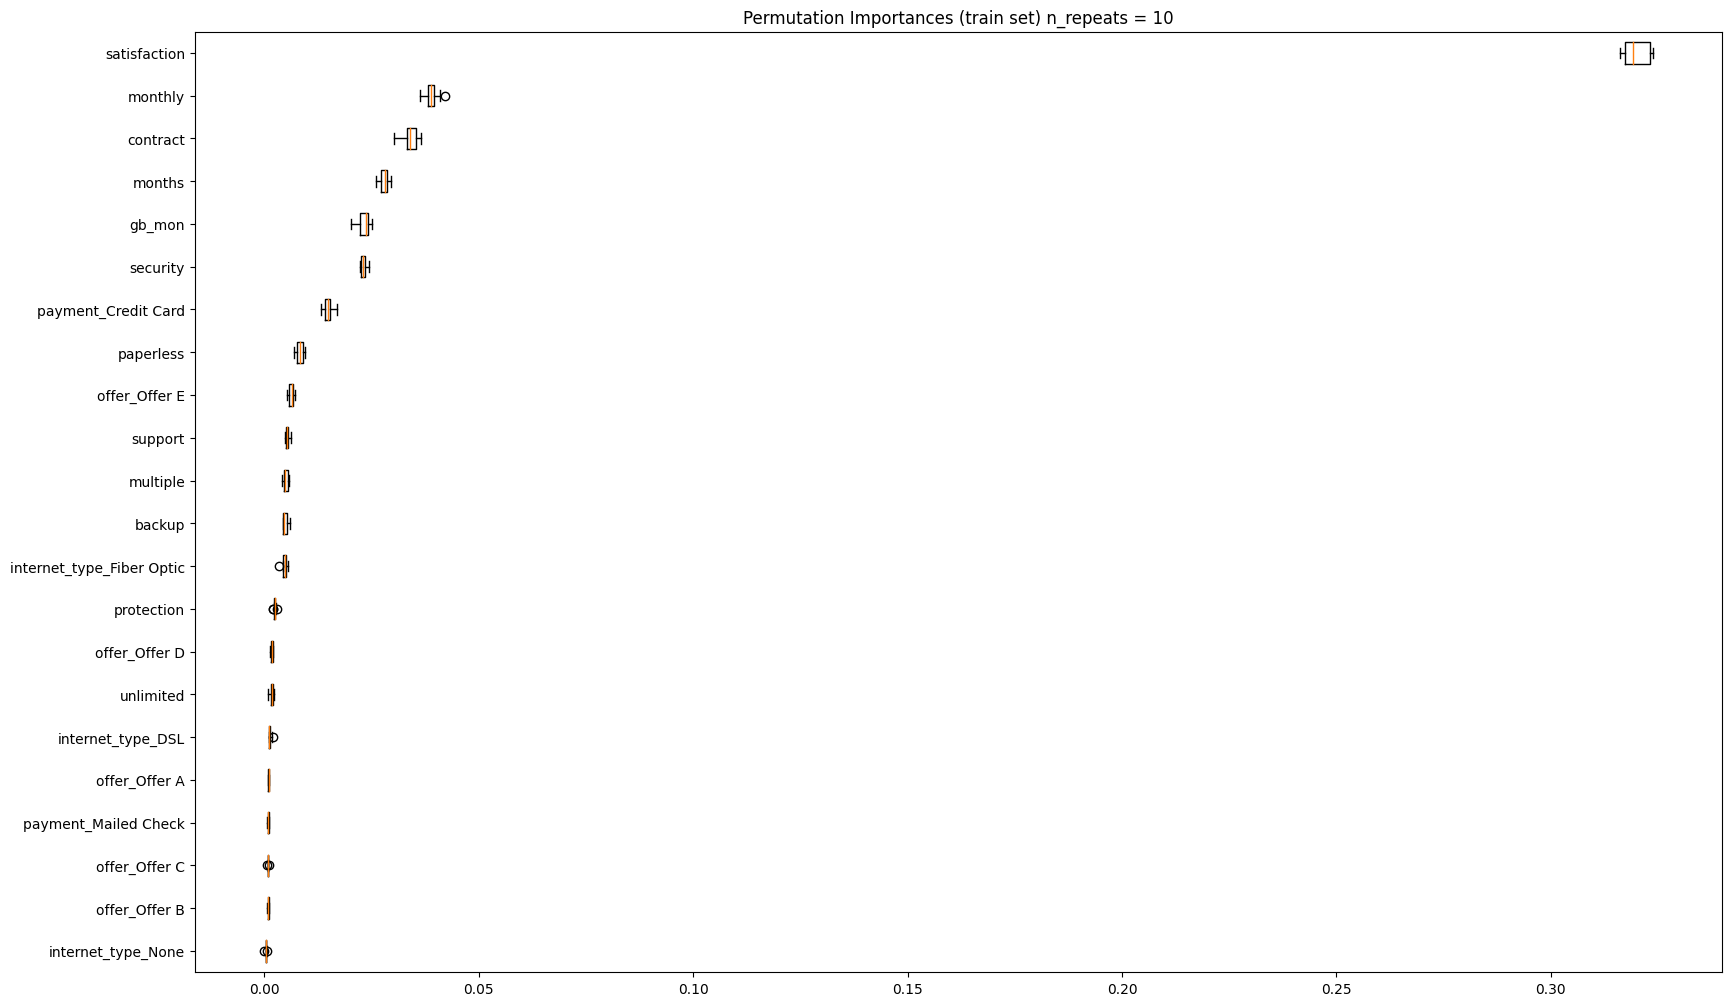

In [0]:
sorted_idx = permutation_feature_custom1.importances_mean.argsort()

fig, ax = plt.subplots()
fig.set_figwidth(16)
fig.set_figheight(10)
fig.tight_layout()
ax.boxplot(permutation_feature_custom1.importances[sorted_idx].T, vert=False, labels=x_v8train.columns[sorted_idx])
ax.set_title("Permutation Importances (train set) n_repeats = 10")
plt.show()

In [0]:
# we can see not much has changed 

In [0]:
# now lets look at a partial dependency plot (PDP) for the important features

In [0]:
from sklearn.inspection import PartialDependenceDisplay

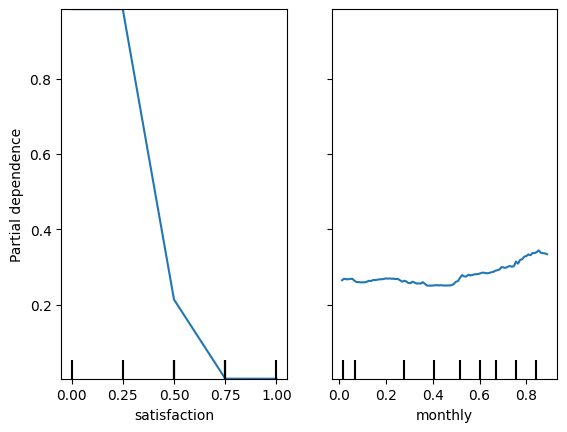

In [0]:
PartialDependenceDisplay.from_estimator(estimator = black_box_model, X = x_v8train, features = ['satisfaction', 'monthly'],
                                        random_state = 123)

In [0]:
# lets look at satisfaction first. we can see that a satisfaction of 0 (low satisfaction) has a very high partial dependence (1.0) with a 
# very high probability to churn
# as the satisfaction goes up to 0.5 suddenly there is a very low partial dependence (0.2) which indicates a low probability of churning
# and then when it hits 1 it goes down to 0 which is a very low chance of churning

# for monthly we can see that, in general, as the monthly bill goes up, the partial dependence goes up which slightly increases 
# the probability for churn

In [0]:
# now lets move on to global surrogate models

In [0]:
lr_surrogate = LogisticRegression(max_iter = 1000, random_state = 123, penalty = 'l1', solver = 'liblinear')

lr_surrogate.fit(x_v8test, black_box_model_preds)

LogisticRegression(max_iter=1000, penalty='l1', random_state=123,
                   solver='liblinear')

In [0]:
lr_surrogate_preds = lr_surrogate.predict(x_v8test)

In [0]:
lr_surrogate_train_score = lr_surrogate.score(x_v8train, y_v8train)
lr_surrogate_test_score = lr_surrogate.score(x_v8test, y_v8test)

print(lr_surrogate.score(x_v8train, y_v8train))
print(lr_surrogate.score(x_v8test, y_v8test))

# great test accuracy and generalization.

0.9508342208022719
0.9545777146912704


In [0]:
# Extract and sort feature coefficients
def get_feature_coefs(regression_model):
    coef_dict = {}
    for coef, feat in zip(regression_model.coef_[0, :], x_v8test.columns):
        if abs(coef) >= 0.01:
            coef_dict[feat] = coef
    coef_dict = {k: v for k, v in sorted(coef_dict.items(), key=lambda item: item[1])}
    return coef_dict

In [0]:
coef_dict = get_feature_coefs(lr_surrogate)
coef_dict

{'satisfaction': -20.3605714952014,
 'contract': -2.5761965474156985,
 'months': -2.26086637338389,
 'security': -1.9576333481759844,
 'gb_mon': -1.1292388812333005,
 'payment_Credit Card': -1.1098398718681826,
 'offer_Offer C': -0.6185349404943816,
 'offer_Offer D': -0.3154863575323547,
 'support': -0.27371575997598063,
 'backup': 0.11381196067309375,
 'offer_Offer E': 0.27696808668443074,
 'payment_Mailed Check': 0.30454976499023606,
 'unlimited': 0.42256226776696837,
 'multiple': 0.4600586873690583,
 'paperless': 0.6262680049202453,
 'internet_type_Fiber Optic': 1.211942356383833}

In [0]:
# Generate bar colors based on if value is negative or positive
def get_bar_colors(values):
    color_vals = []
    for val in values:
        if val <= 0:
            color_vals.append('g')
        else:
            color_vals.append('r')
    return color_vals

# Visualize coefficients
def visualize_coefs(coef_dict):
    features = list(coef_dict.keys())
    values = list(coef_dict.values())
    y_pos = np.arange(len(features))
    color_vals = get_bar_colors(values)
    plt.rcdefaults()
    fig, ax = plt.subplots()
    ax.barh(y_pos, values, align='center', color=color_vals)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    # labels read top-to-bottom
    ax.invert_yaxis()  
    ax.invert_xaxis()
    ax.set_xlabel('Feature Coefficients')
    ax.set_title('')
    plt.show()
    

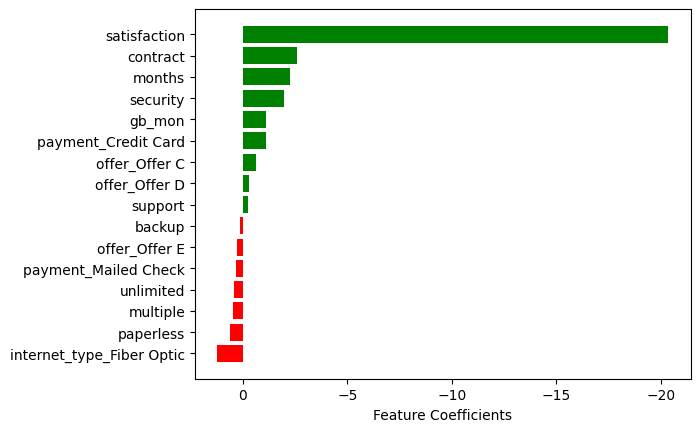

In [0]:
visualize_coefs(coef_dict)

In [0]:
# here through the global surrogate model we can see which features are important to prevent churn

In [0]:
# lets try a global surrogate model with decision tree instead of logistic regression

In [0]:
dt_surrogate = DecisionTreeClassifier(max_depth = 5, random_state = 123, max_features=10)

dt_surrogate.fit(x_v8test, black_box_model_preds)

DecisionTreeClassifier(max_depth=5, max_features=10, random_state=123)

In [0]:
dt_surrogate_preds = dt_surrogate.predict(x_v8test)

In [0]:
dt_surrogate_train_score = dt_surrogate.score(x_v8train, y_v8train)
dt_surrogate_test_score = dt_surrogate.score(x_v8test, y_v8test)

print(dt_surrogate.score(x_v8train, y_v8train))
print(dt_surrogate.score(x_v8test, y_v8test))

# a little lower test accuracy than logistic regression. but still good generalization

0.9259850905218318
0.9368346344925479


In [0]:
from sklearn.tree import export_text

In [0]:
tree_surrogate = export_text(dt_surrogate, feature_names=list(x_v8train.columns))

In [0]:
print(tree_surrogate)

|--- contract <= 0.25
|   |--- internet_type_Fiber Optic <= 0.50
|   |   |--- payment_Credit Card <= 0.50
|   |   |   |--- satisfaction <= 0.38
|   |   |   |   |--- class: 1
|   |   |   |--- satisfaction >  0.38
|   |   |   |   |--- satisfaction <= 0.62
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- satisfaction >  0.62
|   |   |   |   |   |--- class: 0
|   |   |--- payment_Credit Card >  0.50
|   |   |   |--- offer_Offer D <= 0.50
|   |   |   |   |--- gb_mon <= 0.31
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- gb_mon >  0.31
|   |   |   |   |   |--- class: 0
|   |   |   |--- offer_Offer D >  0.50
|   |   |   |   |--- class: 0
|   |--- internet_type_Fiber Optic >  0.50
|   |   |--- satisfaction <= 0.38
|   |   |   |--- class: 1
|   |   |--- satisfaction >  0.38
|   |   |   |--- months <= 0.12
|   |   |   |   |--- satisfaction <= 0.62
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- satisfaction >  0.62
|   |   |   |   |   |--- class: 0
|   |   |   |--- months > 

In [0]:
# contract is relied on most, then satisfaction, then internet type

In [0]:
!pip install lime==0.2.0.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 35.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 60.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 30.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 49.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 55.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 54.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.6/317.6 kB 67.4 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283839 sha256=87206f3bfc5ce1ef8fdffb5d83bd907113ac9b9dd2674fd8b0734432e91daec9
  Stored in directory: /home/spark-78489369-4058-4785-9d38-2a/.cache/pip/wheels/ac/fc/ba/bc2e218408e730b7

In [0]:
# import lime to azure ML

import sys

!{sys.executable} -m pip install lime


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [0]:
import lime.lime_tabular

In [0]:
lime_surrogate = lime.lime_tabular.LimeTabularExplainer(
    training_data = x_v8test.values,
    mode = 'classification',
    class_names = ['Not Changing', 'Changing'],
    feature_names=list(x_v8train.columns),
    random_state=123,
    verbose=True)


In [0]:
selected_instance = x_v8test.iloc[[19]]
selected_instance

,months,multiple,gb_mon,security,backup,protection,support,unlimited,contract,paperless,monthly,satisfaction,payment_Credit Card,payment_Mailed Check,internet_type_DSL,internet_type_Fiber Optic,internet_type_None,offer_Offer A,offer_Offer B,offer_Offer C,offer_Offer D,offer_Offer E
5139,1.0,0,0.0,0,0,0,0,0,1.0,0,0.023383,0.5,1,0,0,0,1,0,1,0,0,0


In [0]:
y_v8test.iloc[19]

# we can see he did not churn 

0

In [0]:
selected_instance_transform = selected_instance.values.reshape(-1)

/databricks/python/lib/python3.10/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Intercept 0.03553217466211417
Prediction_local [0.7019123]
Right: 0.0


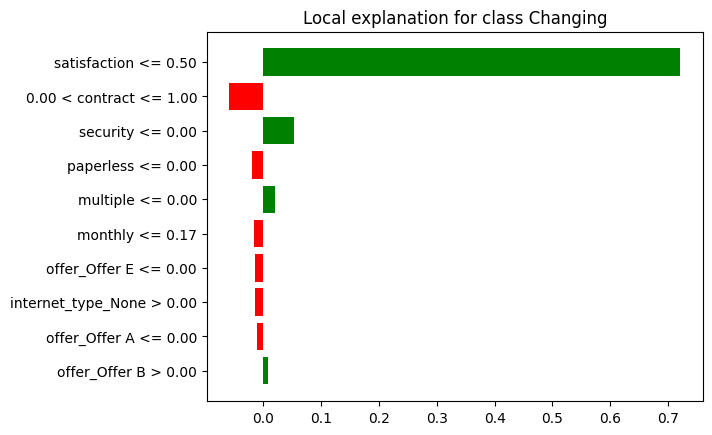

In [0]:
exp = lime_surrogate.explain_instance(selected_instance_transform,
                                 black_box_model.predict_proba,
                                 num_features = 10)
exp.as_pyplot_figure();

In [0]:
# this shows us why this specific customer did not churn. there was a huge influence from satisfaction which overtook all the negatives. 
# security seem to be decently big too

In [0]:
lr_surrogate_train_score
LogisticRegression(max_iter = 1000, random_state = 123, penalty = 'l1', solver = 'liblinear')
dt_surrogate_train_score
DecisionTreeClassifier(max_depth = 5, random_state = 123, max_features=10)

DecisionTreeClassifier(max_depth=5, max_features=10, random_state=123)

In [0]:
globalsurrogate_table = pd.DataFrame(
    [
        ["""LogisticRegression(max_iter = 1000, random_state = 123, penalty = 'l1', solver = 'liblinear')""", 
         stacking_custom1_train_score, stacking_custom1_test_score],
        ["""DecisionTreeClassifier(max_depth = 5, random_state = 123, max_features=10)""", 
         stacking_train_score, stacking_test_score]
    ],
    columns = ["Parameters", "Train score", "Test score",],
    index = ["Logistic Regression Global Surrogate", 
             "Decision Tree Global Surrogate"]
)

globalsurrogate_table.index.name = "What We Changed"

display(Markdown("##### Global Surrogate: Models Performance Comparison"))

display(
    globalsurrogate_table.style
    .set_properties(**{"white-space": "normal"})
     .highlight_max(subset=["Test score"], props="font-weight: bold;")
)


##### Global Surrogate: Models Performance Comparison

,Parameters,Train score,Test score
What We Changed,,,
Logistic Regression Global Surrogate,"LogisticRegression(max_iter = 1000, random_state = 123, penalty = 'l1', solver = 'liblinear')",0.937877,0.934705
Decision Tree Global Surrogate,"DecisionTreeClassifier(max_depth = 5, random_state = 123, max_features=10)",0.962016,0.958836


In [0]:
# finally lets look at some model balancing methods

In [0]:
data = spark.table(
    "churn_project_databricks.default.churndata_processed"
).toPandas()

In [0]:
x_v9 = data.drop("churn_value", axis = 1)
y_v9 = data["churn_value"]

x_v9train, x_v9test, y_v9train, y_v9test = train_test_split(x_v9, y_v9, test_size = 0.2, stratify = y_v9, random_state = 123)

In [0]:
data["churn_value"].value_counts()

# we can see here that the response variable balance is very moderately imbalanced. it will see a slight benefit from balancing so 
# lets try some.

0    5174
1    1869
Name: churn_value, dtype: int64

In [0]:
# lets see some conventional scores for a simple logistic regression model

lr_balance = LogisticRegression(random_state = 123, max_iter = 1000)

lr_balance.fit(x_v9train, y_v9train)
lr_balance_preds = lr_balance.predict(x_v9test)

In [0]:
lr_balance_train_score = lr_balance.score(x_v9train, y_v9train)
lr_balance_test_score = lr_balance.score(x_v9test, y_v9test)

print(lr_balance.score(x_v9train, y_v9train))
print(lr_balance.score(x_v9test, y_v9test))

# the test accuracy is looking pretty good with ~0.95 and is slightly overfit

0.95580404685836
0.9467707594038325


In [0]:
from sklearn.metrics import roc_auc_score

In [0]:
lr_balance_precision, lr_balance_recall, lr_balance_fscore, lr_balance_support = precision_recall_fscore_support(y_v9test, 
                                                                            lr_balance_preds, beta = 5, pos_label = 1, average = 'binary')

lr_balance_auc = roc_auc_score(y_v9test, lr_balance_preds)

print(f"precision is: {lr_balance_precision:.2f}")
print(f"recall is: {lr_balance_recall:.2f}")
print(f"fscore is: {lr_balance_fscore:.2f}")
print(f"auc is: {lr_balance_auc:.2f}")

precision is: 0.92
recall is: 0.88
fscore is: 0.88
auc is: 0.93


In [0]:
# lets try an oversampling technique called SMOTE (Synthetic Minority Oversampling Technique)

In [0]:
# import imbalanced-learn into azure ML

import sys

!{sys.executable} -m pip install imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 38.5 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 2.2.0
    Not uninstalling threadpoolctl at /databricks/python3/lib/python3.10/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-78489369-4058-4785-9d38-2ac97b11e607
    Can't uninstall 'threadpoolctl'. No files were found to uninstall.
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.1.1
    Not uninstalling scikit-learn at /databricks/python3/lib/python3.10/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-78489369-4058-4785-9d38-2ac97b11e607
    Can't uninstall 'scikit-learn'. No files were found to uninstall.

[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [0]:
%pip install imbalanced-learn==0.10.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.0/226.0 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.2
    Uninstalling imbalanced-learn-0.14.2:
      Successfully uninstalled imbalanced-learn-0.14.2
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from imblearn.over_sampling import SMOTE

In [0]:
smote_sampler = SMOTE(random_state = 123)

In [0]:
x_smo, y_smo = smote_sampler.fit_resample(x_v9train, y_v9train)


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fc66e5939a0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


<Axes: >

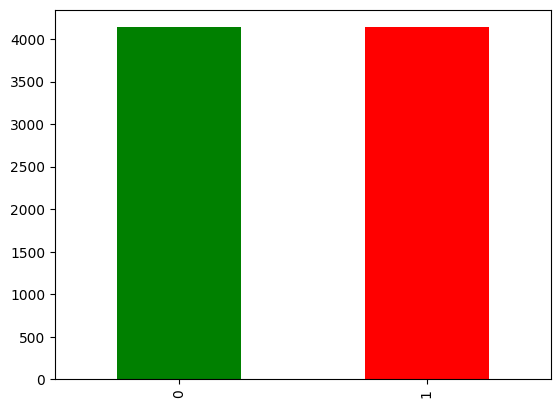

In [0]:
y_smo.value_counts().plot.bar(color = ['green', 'red'])

In [0]:
lr_balance.fit(x_smo, y_smo)
lr_balance_smote_preds = lr_balance.predict(x_v9test)

In [0]:
lr_balance_smote_precision, lr_balance_smote_recall, lr_balance_smote_fscore, lr_balance_smote_support = precision_recall_fscore_support(
                                                            y_v9test, lr_balance_smote_preds, beta = 5, pos_label = 1, average = 'binary')

lr_balance_smote_auc = roc_auc_score(y_v9test, lr_balance_smote_preds)

print(f"precision is: {lr_balance_smote_precision:.2f}")
print(f"recall is: {lr_balance_smote_recall:.2f}")
print(f"fscore is: {lr_balance_smote_fscore:.2f}")
print(f"auc is: {lr_balance_smote_auc:.2f}")



precision is: 0.84
recall is: 0.93
fscore is: 0.93
auc is: 0.93


In [0]:
# logistic regression without SMOTE
# precision is: 0.91
# recall is: 0.88
# fscore is: 0.88
# auc is: 0.93

# Since SMOTES primary purpose is to improve recall and fscore 
# it looks like recall and fscore increased a lot. there was a sacrifice in precision but this might be completely worth it depending
# on business goal

In [0]:
# lets try another approach for imbalanced data. 
# class reweighing.

In [0]:
lr_balance_reweighing = LogisticRegression(random_state = 123, max_iter = 1000, class_weight = {0:1.37, 1:3.70})

In [0]:
lr_balance_reweighing.fit(x_v9train, y_v9train)
lr_balance_reweighing_preds = lr_balance_reweighing.predict(x_v9test)

In [0]:
lr_balance_reweighing_precision, lr_balance_reweighing_recall, lr_balance_reweighing_fscore, lr_balance_reweighing_support = precision_recall_fscore_support(y_v9test, lr_balance_reweighing_preds, beta = 5, pos_label = 1,
                                                                     average = 'binary')

lr_balance_reweighing_auc = roc_auc_score(y_v9test, lr_balance_reweighing_preds)

print(f"precision is: {lr_balance_reweighing_precision:.2f}")
print(f"recall is: {lr_balance_reweighing_recall:.2f}")
print(f"fscore is: {lr_balance_reweighing_fscore:.2f}")
print(f"auc is: {lr_balance_reweighing_auc:.2f}")

precision is: 0.81
recall is: 0.94
fscore is: 0.94
auc is: 0.93


In [0]:
# previous scores:
# precision is: 0.91
# recall is: 0.88
# fscore is: 0.88
# auc is: 0.93

# we can see that recall and fscore shot up. 
# we have definitely sacrified some precision (0.91 vs. 0.81) but this might be fine based on our business focus

In [0]:
# now lets try the balancing methods using random forest model instead of logistic regression 

In [0]:
# lets get the best recall score gridsearch parameters for random forest

rf_balancing = RandomForestClassifier(bootstrap = True, class_weight = None)

In [0]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

In [0]:
search = GridSearchCV(estimator = rf_balancing, param_grid = param_grid, scoring = 'recall')

In [0]:
search.fit(x_v9train, y_v9train)


GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='recall')

In [0]:
search.best_score_

0.8802675585284281

In [0]:
search.best_params_

{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}

In [0]:
rf_balancing_gridsearch_preds = search.best_estimator_.predict(x_v9test)

In [0]:
rf_balancing_gridsearch_precision, rf_balancing_gridsearch_recall, rf_balancing_gridsearch_fscore, rf_balancing_gridsearch_support = precision_recall_fscore_support(y_v9test, rf_balancing_gridsearch_preds, beta = 5, pos_label = 1,
                                                                     average = 'binary')

rf_balancing_gridsearch_auc = roc_auc_score(y_v9test, rf_balancing_gridsearch_preds)

print(f"precision is: {rf_balancing_gridsearch_precision:.2f}")
print(f"recall is: {rf_balancing_gridsearch_recall:.2f}")
print(f"fscore is: {rf_balancing_gridsearch_fscore:.2f}")
print(f"auc is: {rf_balancing_gridsearch_auc:.2f}")

precision is: 0.91
recall is: 0.88
fscore is: 0.88
auc is: 0.93


In [0]:
# logistic regression scores

# precision is: 0.91
# recall is: 0.88
# fscore is: 0.88
# auc is: 0.93

# basically the same except 0.1 less auc score

In [0]:
# lets apply class reweighing to random forest

In [0]:
rf_reweighing = RandomForestClassifier(bootstrap = True, class_weight = {0:1.37, 1:3.70}, max_depth = 15, 
                                       min_samples_split = 2, n_estimators = 100)

In [0]:
rf_reweighing.fit(x_v9train, y_v9train)

rf_reweighing_preds = rf_reweighing.predict(x_v9test)

In [0]:
rf_reweighing_precision, rf_reweighing_recall, rf_reweighing_fscore, rf_reweighing_support = precision_recall_fscore_support(
                                                y_v9test, rf_reweighing_preds, beta = 5, pos_label = 1, average = 'binary')

rf_reweighing_auc = roc_auc_score(y_v9test, rf_reweighing_preds)

print(f"precision is: {rf_reweighing_precision:.2f}")
print(f"recall is: {rf_reweighing_recall:.2f}")
print(f"fscore is: {rf_reweighing_fscore:.2f}")
print(f"auc is: {rf_reweighing_auc:.2f}")


precision is: 0.90
recall is: 0.90
fscore is: 0.90
auc is: 0.93


In [0]:
# random forest scores (no reweighing)

# precision is: 0.91
# recall is: 0.88
# fscore is: 0.88
# auc is: 0.92

# we can see the reweighing sacrifices some precision for a similar numerical increase of recall and fscore
# and a slightly better auc
# this might be very worth it depending on business goal

In [0]:
# now lets try SMOTE and random under sampler for random forest

In [0]:
from imblearn.under_sampling import RandomUnderSampler


In [0]:
# SMOTE first

x_smo, y_smo = smote_sampler.fit_resample(x_v9train, y_v9train)

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fc65740acb0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


In [0]:
search.best_estimator_.fit(x_smo, y_smo)
rf_balancing_gridsearch_smote_preds = search.best_estimator_.predict(x_v9test)

In [0]:
rf_reweighing_smote_precision, rf_reweighing_smote_recall, rf_reweighing_smote_fscore, rf_reweighing_smote_support = precision_recall_fscore_support(
                                                y_v9test, rf_balancing_gridsearch_smote_preds, beta = 5, pos_label = 1, average = 'binary')

rf_reweighing_smote_auc = roc_auc_score(y_v9test, rf_balancing_gridsearch_smote_preds)

print(f"precision is: {rf_reweighing_smote_precision:.2f}")
print(f"recall is: {rf_reweighing_smote_recall:.2f}")
print(f"fscore is: {rf_reweighing_smote_fscore:.2f}")
print(f"auc is: {rf_reweighing_smote_auc:.2f}")


precision is: 0.90
recall is: 0.90
fscore is: 0.90
auc is: 0.93


In [0]:
# random forest scores (no smote)

# precision is: 0.91
# recall is: 0.88
# fscore is: 0.88
# auc is: 0.92

# looks like the recall and fscore got better with a similar sacrifice in precision. 

In [0]:
# now randomundersampler

In [0]:
under_sampler = RandomUnderSampler(random_state = 123)

In [0]:
x_under, y_under = under_sampler.fit_resample(x_v9train, y_v9train)

In [0]:
search.best_estimator_.fit(x_under, y_under)
rf_balancing_gridsearch_randomunder_preds = search.best_estimator_.predict(x_v9test)

In [0]:
rf_reweighing_randomunder_precision, rf_reweighing_randomunder_recall, rf_reweighing_randomunder_fscore, rf_reweighing_randomunder_support = precision_recall_fscore_support(
                                                y_v9test, rf_balancing_gridsearch_randomunder_preds, beta = 5, pos_label = 1, average = 'binary')

rf_reweighing_randomunder_auc = roc_auc_score(y_v9test, rf_balancing_gridsearch_randomunder_preds)

print(f"precision is: {rf_reweighing_randomunder_precision:.2f}")
print(f"recall is: {rf_reweighing_randomunder_recall:.2f}")
print(f"fscore is: {rf_reweighing_randomunder_fscore:.2f}")
print(f"auc is: {rf_reweighing_randomunder_auc:.2f}")


precision is: 0.82
recall is: 0.94
fscore is: 0.94
auc is: 0.94


In [0]:
# random forest scores (no smote)

# precision is: 0.91
# recall is: 0.88
# fscore is: 0.88
# auc is: 0.92

# looks like the recall and fscore got better with a bigger sacrifice in precision. 

In [0]:
resampling_logisticregression_table = pd.DataFrame(
    [
        ["""max_iter = 1000""", 
         lr_balance_precision, lr_balance_recall, lr_balance_fscore, lr_balance_auc],
        ["""Default""", 
         lr_balance_smote_precision, lr_balance_smote_recall, lr_balance_smote_fscore, lr_balance_smote_auc],
        ["""class_weight = {0:1.37, 1:3.70}""",
         lr_balance_reweighing_precision, lr_balance_reweighing_recall, lr_balance_reweighing_fscore, lr_balance_reweighing_auc]
    ],
    columns = ["Parameters", "Precision", "Recall", "Fscore", "AUC"],
    index = ["Logistic Regression (no balancing)", 
             "Logistic Regression (SMOTE)",
             "Logistic Regression (class reweighing)"]
)

resampling_logisticregression_table.index.name = "Balancing Methods"

display(Markdown("##### Resampling (Logistic Regression): Methods Performance Comparison"))

display(
    resampling_logisticregression_table.style
    .set_properties(**{"white-space": "normal"})
     .highlight_max(subset=["Recall", "Fscore"], props="font-weight: bold;")
)


##### Resampling (Logistic Regression): Methods Performance Comparison

,Parameters,Precision,Recall,Fscore,AUC
Balancing Methods,,,,,
Logistic Regression (no balancing),max_iter = 1000,0.916435,0.879679,0.881038,0.925347
Logistic Regression (SMOTE),Default,0.838942,0.933155,0.929142,0.934210
Logistic Regression (class reweighing),"class_weight = {0:1.37, 1:3.70}",0.809633,0.943850,0.937870,0.931829


In [0]:
# the best recall and fscores for logistic regression were both from the class reweighing method

In [0]:
resampling_randomforest_table = pd.DataFrame(
    [
        ["""bootstrap = True, class_weight = None, max_depth = 15, 
                                       min_samples_split = 2, n_estimators = 100""", 
         rf_balancing_gridsearch_precision, rf_balancing_gridsearch_recall, rf_balancing_gridsearch_fscore, rf_balancing_gridsearch_auc],
        ["""bootstrap = True, class_weight = {0:1.37, 1:3.70}, max_depth = 15, 
                                       min_samples_split = 2, n_estimators = 100""", 
         rf_reweighing_precision, rf_reweighing_recall, rf_reweighing_fscore, rf_reweighing_auc],
        ["""Default""",
         rf_reweighing_smote_precision, rf_reweighing_smote_recall, rf_reweighing_smote_fscore, rf_reweighing_smote_auc],
        ["""Default""",
        rf_reweighing_randomunder_precision, rf_reweighing_randomunder_recall, rf_reweighing_randomunder_fscore, 
         rf_reweighing_randomunder_auc]
    ],
    columns = ["Parameters", "Precision", "Recall", "Fscore", "AUC"],
    index = ["Random Forest (no balancing)", 
             "Random Forest (class reweighing)",
             "Random Forest (SMOTE)",
             "Random Forest (random under sampling)"]
)

resampling_randomforest_table.index.name = "Balancing Methods"

display(Markdown("##### Resampling (Random Forest): Methods Performance Comparison"))

display(
    resampling_randomforest_table.style
    .set_properties(**{"white-space": "normal"})
     .highlight_max(subset=["Recall", "Fscore"], props="font-weight: bold;")
)


##### Resampling (Random Forest): Methods Performance Comparison

,Parameters,Precision,Recall,Fscore,AUC
Balancing Methods,,,,,
Random Forest (no balancing),"bootstrap = True, class_weight = None, max_depth = 15, min_samples_split = 2, n_estimators = 100",0.914127,0.882353,0.883534,0.926201
Random Forest (class reweighing),"bootstrap = True, class_weight = {0:1.37, 1:3.70}, max_depth = 15, min_samples_split = 2, n_estimators = 100",0.896552,0.903743,0.903465,0.933031
Random Forest (SMOTE),Default,0.896552,0.903743,0.903465,0.933031
Random Forest (random under sampling),Default,0.822844,0.943850,0.938542,0.935210


In [0]:
# the best recall and fscores for random forest were both from the random under sampling method